In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import numpy as np
from scipy.optimize import curve_fit
from glob import glob
from scipy.signal import savgol_filter
import seaborn as sns
from pathlib import Path 
import re
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In this notebook, you will work on the plate reader growth data of different  𝑆.𝑐𝑒𝑟𝑒𝑣𝑖𝑠𝑖𝑎𝑒 strains containing various combinations of the GAL1 and DOA1 promoter with either the GAL1 or DOA1 gene + mScarlet fluorophore exposed to different carbon source transitions.

Firstly, we want to focus on how the strain alterations affect the growth in each strain, especially compared to the wildtype strain. Some of the strains used are detailed in **panel A** of **Figure 1** below. 

The strains which are not depicted are: 

- YET784 = P<sub>Gal1</sub> - DOA1
- YET963 = P<sub>Doa1</sub> - mScarlet
  
All strains and their descriptions can be found in "Yeast strains.pdf"

- For these 2 missing strains that are not depicted, do you have a clear idea of their strains characteristics?

Secondly, we want to focus how the different carbon source transitions affect growth in every strain. The growth protocol is detailed in the word document found in this folder titled "Plate Reader Exp Set Up.pdf" and is summarized in the schematic shown below in **panel B**. The different transitions are:

'GLUGLU', 'GALGAL', 'RAFRAF', 'GLUGAL', 'GLURAF', 'RAFGAL', 'GALGLU', 'RAFGLU', 'GALRAF'. 

- Do you already have certain expectations of which transitions are faster or slower growers?

![title](imgs/SC_practical_growth_reader_schematic.png)

***

# Load and format data.

In [2]:
#Parse the data files
files = glob(fr'Plate Reader Data\*.xlsx')
files

['Plate Reader Data\\YET784_DATA_1312.xlsx',
 'Plate Reader Data\\YET858_DATA_2305.xlsx',
 'Plate Reader Data\\YET911_DATA_2401.xlsx',
 'Plate Reader Data\\YET937_DATA_2401.xlsx',
 'Plate Reader Data\\YET938_DATA_2701.xlsx',
 'Plate Reader Data\\YET962_DATA_2901.xlsx',
 'Plate Reader Data\\YET963_DATA_2901.xlsx']

In [3]:
# Load different files as a pandas dataframe using the index
df = pd.read_excel(files[1], sheet_name="Table All Cycles")

# Display the first few rows of the DataFrame
df.head(15) 

,User: USER,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49
0,Path: C:\Program Files (x86)\BMG\SPECTROstar N...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Test ID: 485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Test Name: MO_OD600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Date: 21/05/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Time: 18:59:07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ID1: MO_OD600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ID2: Absorbance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"ID3: 21/05/2025,18:59:06",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Absorbance,NaN,NaN,Absorbance values are displayed as OD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- What do you notice about the first 15 rows of the dataframe? It seems that there is some metadata that should not be included. Are you able to remove it? The resulting dataframe should only contain the raw data columns A1-F8 and the time column.

In [4]:
# your code here: 
#initialise df_cleaned

# 1. Set the column headers based on the 12th row of the dataframe (index 11)
df_cleaned = df.copy()
df_cleaned.columns = df_cleaned.iloc[11]

# 2. Remove the first 12 rows
df_cleaned = df_cleaned.iloc[12:]

# 3. Reset the index after dropping rows (otherwise the indexing of the dataframe will be off)
df_cleaned = df_cleaned.reset_index(drop=True)

# 4. Drop the first column named Well*
df_cleaned = df_cleaned.drop(columns=["Well"])

# 5. Rename the new first column to 'Time'
df_cleaned = df_cleaned.rename(columns={df_cleaned.columns[0]: "Time"})

# Display result
df_cleaned.head()


11,Time,A1,A2,A3,A4,A5,A6,A7,A8,B1,...,E7,E8,F1,F2,F3,F4,F5,F6,F7,F8
0,Time,Sample X48,Sample X47,Sample X46,Sample X45,Sample X44,Sample X43,Sample X42,Sample X41,Sample X40,...,Sample X10,Sample X9,Sample X8,Sample X7,Sample X6,Sample X5,Sample X4,Sample X3,Sample X2,Sample X1
1,0 h,0.08,0.084,0.081,0.094,0.092,0.081,0.092,0.08,0.096,...,0.096,0.093,0.079,0.082,0.081,0.089,0.093,0.08,0.082,0.081
2,0 h 10 min,0.081,0.083,0.081,0.093,0.088,0.081,0.091,0.081,0.094,...,0.091,0.093,0.08,0.083,0.081,0.088,0.088,0.081,0.082,0.082
3,0 h 20 min,0.081,0.083,0.082,0.09,0.089,0.082,0.092,0.081,0.093,...,0.089,0.092,0.08,0.084,0.081,0.089,0.086,0.082,0.084,0.081
4,0 h 30 min,0.08,0.084,0.081,0.091,0.089,0.081,0.091,0.081,0.092,...,0.091,0.09,0.079,0.082,0.081,0.087,0.087,0.081,0.083,0.081


The time columns is in a strange format too. Can you convert the data to hours and minutes in the column onto two new columns named "time_hours" and "time_minutes"?

In [5]:
#Your code here:  
df_cleaned["time_minutes"] = df_cleaned["Time"].str.extract(r"(\d+)\s*min").fillna(0).astype(int)
df_cleaned["time_hours"] = df_cleaned["Time"].str.extract(r"(\d+)\s*h").fillna(0).astype(int)

df_cleaned[["Time", "time_hours", "time_minutes"]].head(15)

11,Time,time_hours,time_minutes
0,Time,0,0
1,0 h,0,0
2,0 h 10 min,0,10
3,0 h 20 min,0,20
4,0 h 30 min,0,30
5,0 h 40 min,0,40
6,0 h 50 min,0,50
7,1 h,1,0
8,1 h 10 min,1,10
9,1 h 20 min,1,20


Next, we will start naming the different columns according to the conditions they belong to. Below you can find the plate layout.

![title](imgs/Plate_layout.png)

- Can you fill in the dictionary beneath to map the columns to each condition, ignoring the blanks?

In [6]:
#Map of conditions
#These conditions are valid for the data coming from SPECTROSTAR YZMA; the following list matches the automatic columns 
#name given by the machine to each nutrient transition tested
conditions = {
    "GLUGLU": ["E1", "E2", "E7", "E8"],

    "GALGAL": ["A4", "A5", "E3", "E6"],

    "RAFRAF": ["E4", "E5", "F4", "F5"],

    "GLUGAL": ["B1", "B2", "B7", "B8"],

    "GLURAF": ["C1", "C2", "C7", "C8"],

    "RAFGAL": ["D1", "D2", "D7", "D8"],

    "GALGLU": ["B3", "B4", "B5", "B6"],

    "RAFGLU": ["C3", "C4", "C5", "C6"],

    "GALRAF": ["D3", "D4", "D5", "D6"]
}

In [7]:
all_samples = sum(conditions.values(), [])

rename_dict = {}
for condition, samples in conditions.items():
    rename_dict.update({
        samples[0]: f"{condition}1",
        samples[1]: f"{condition}1",
        samples[2]: f"{condition}2",
        samples[3]: f"{condition}2"
    })

# Rename the columns in the DataFrame
df_renamed = df_cleaned.rename(columns=rename_dict)

# Display the DataFrame with the new column names
df_renamed.head(3)

11,Time,A1,A2,A3,GALGAL1,GALGAL1,A6,A7,A8,GLUGAL1,...,F1,F2,F3,RAFRAF2,RAFRAF2,F6,F7,F8,time_minutes,time_hours
0,Time,Sample X48,Sample X47,Sample X46,Sample X45,Sample X44,Sample X43,Sample X42,Sample X41,Sample X40,...,Sample X8,Sample X7,Sample X6,Sample X5,Sample X4,Sample X3,Sample X2,Sample X1,0,0
1,0 h,0.08,0.084,0.081,0.094,0.092,0.081,0.092,0.08,0.096,...,0.079,0.082,0.081,0.089,0.093,0.08,0.082,0.081,0,0
2,0 h 10 min,0.081,0.083,0.081,0.093,0.088,0.081,0.091,0.081,0.094,...,0.08,0.083,0.081,0.088,0.088,0.081,0.082,0.082,10,0


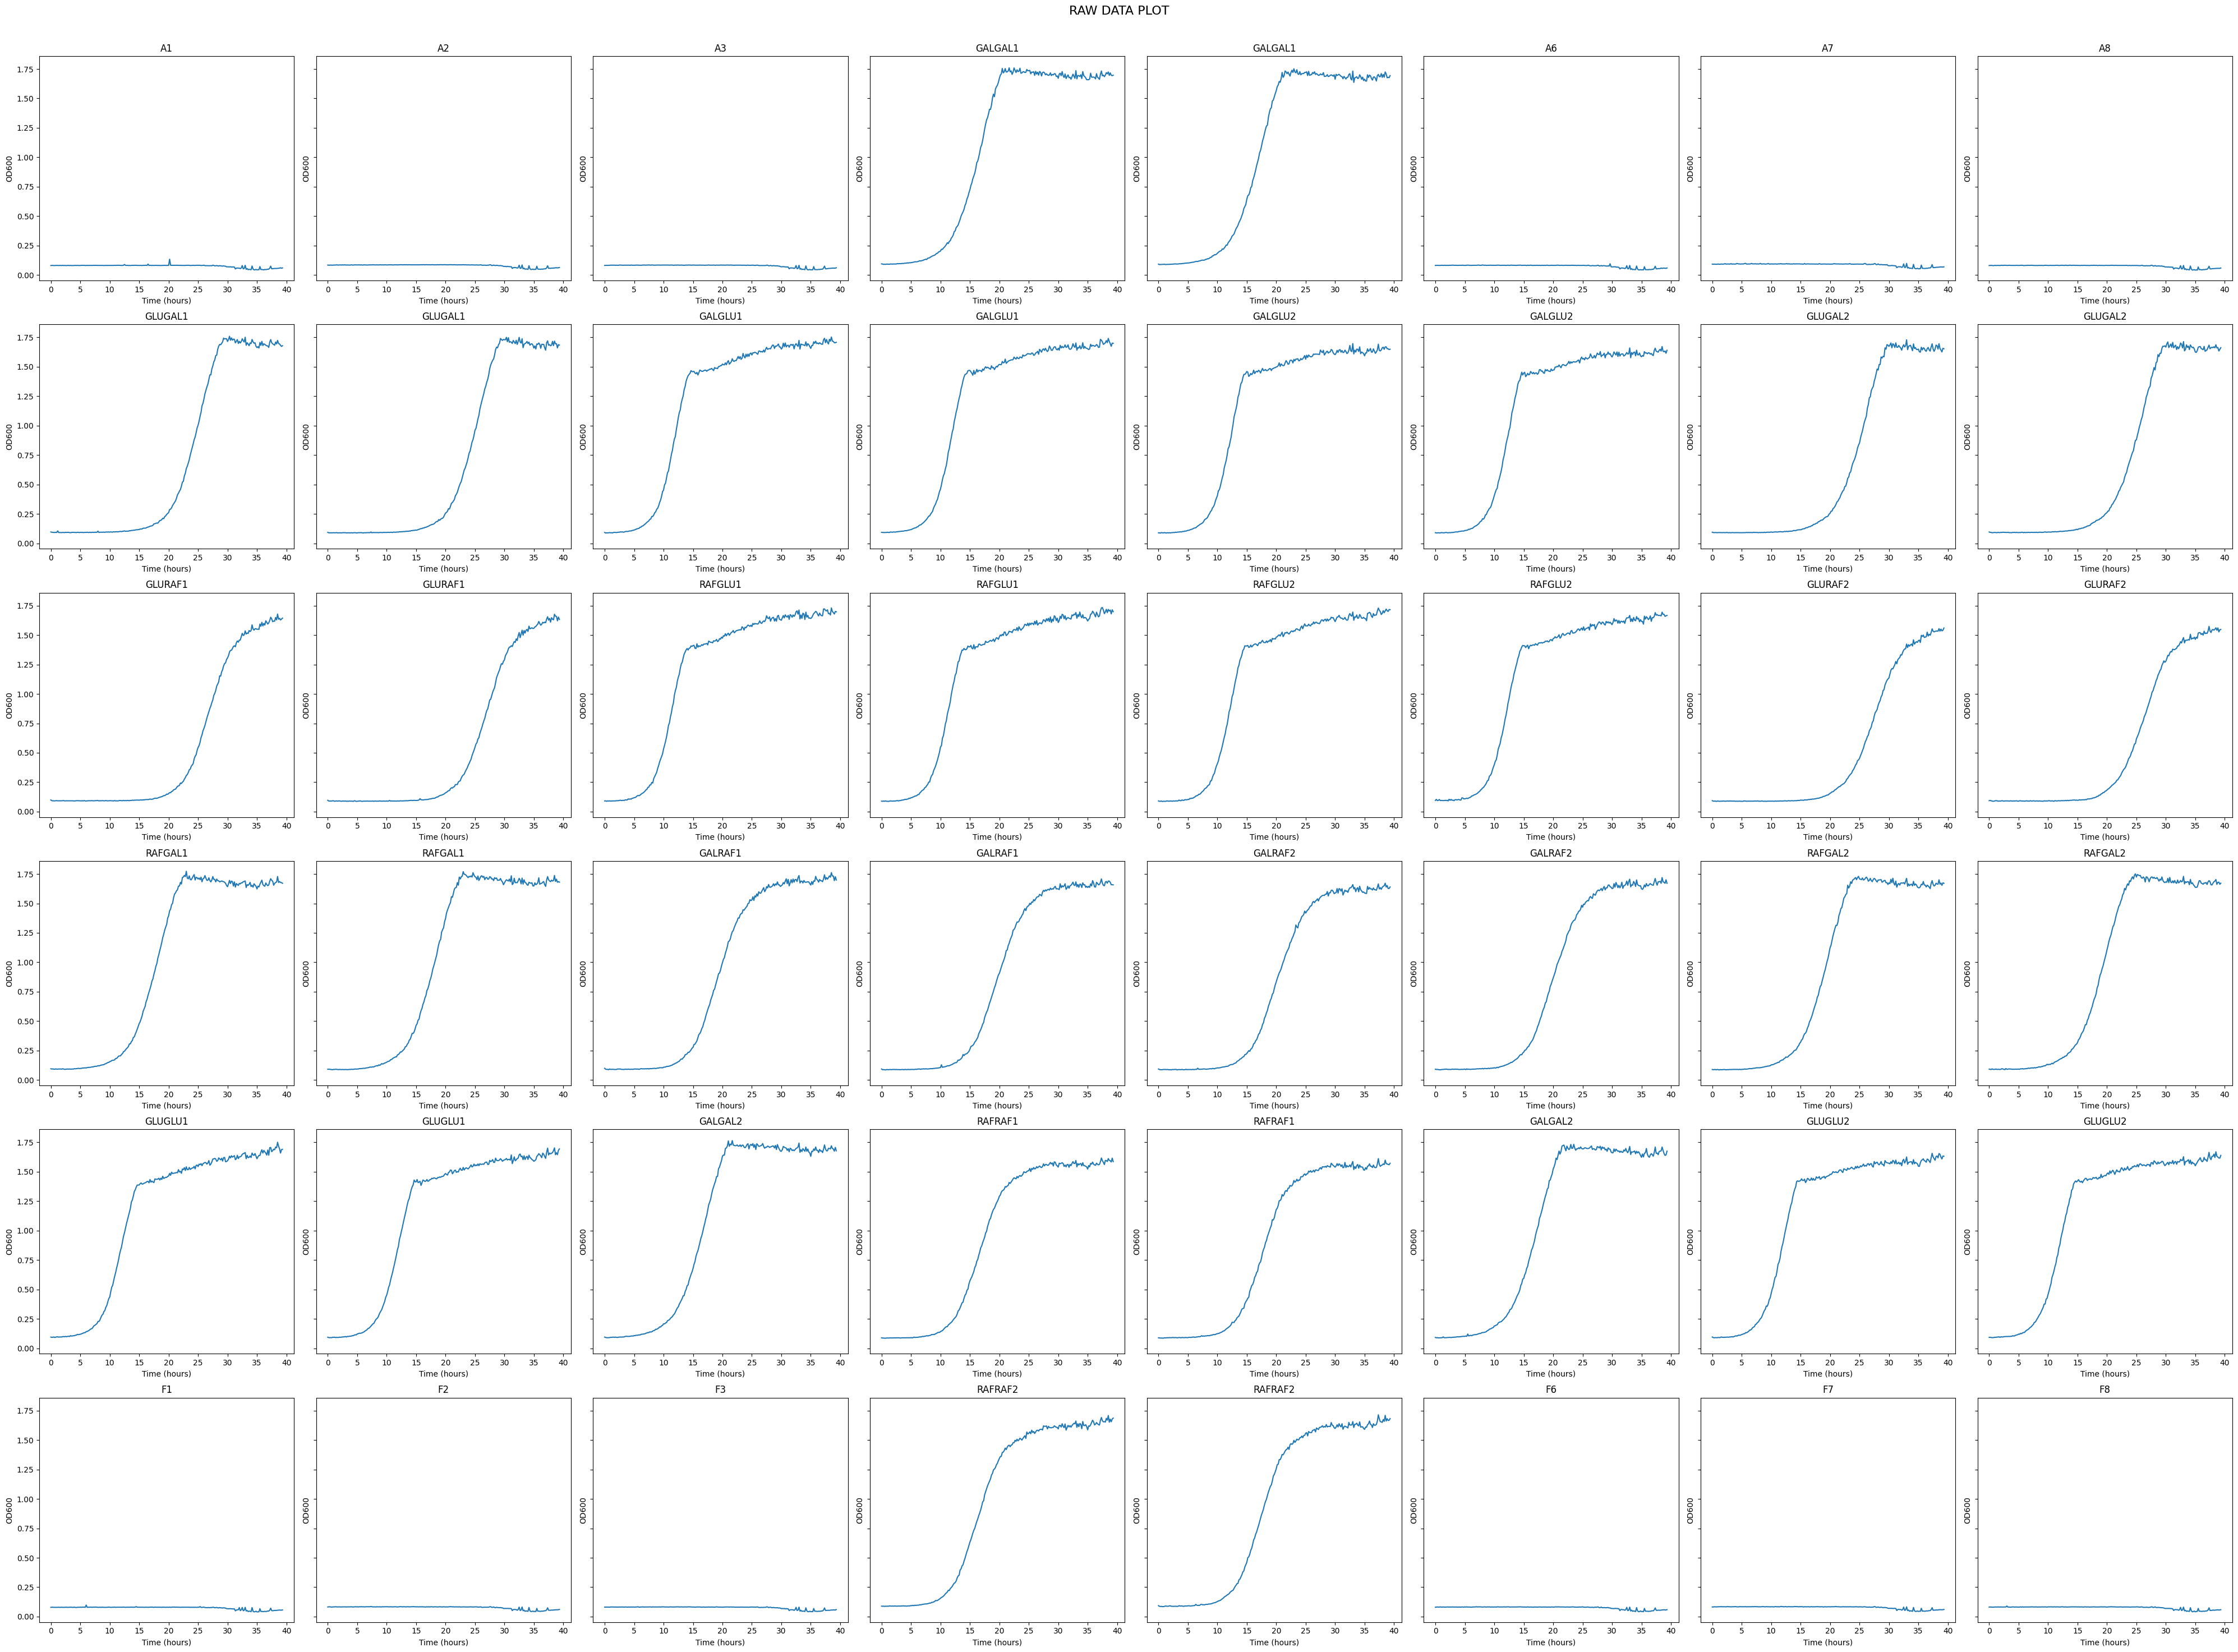

In [22]:
# Create a figure and set the number of subplots (48 subplots, arranged in 6 rows and 8 columns)
num_rows = 6
num_cols = 8
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5), sharey = True)  #6x8 grid of subplots

# Flatten the 2D axes array to 1D for easy indexing
axes = axes.flatten()

# Collect the variable names of the renamed columns, skipping 'time','time_delta','time_in_hours' and 'time_in_minutes'
# or any column contianing something different than raw OD600 values
renamed_columns = [col for col in df_renamed.columns if col not in ['time','time_delta','time_minutes','time_hours']]

# iterate over the renamed columns and plot them below

#### YOUR CODE HERE for iterating over the columns and plotting them in the 48 different subplots ###########################
# Iterate over the renamed columns and plot them in the 48 subplots
plot_index = 0

for col_index in range(len(df_renamed.columns)):

    col = df_renamed.columns[col_index]

    # skip non-OD600 columns
    if col in ['Time', 'time_delta', 'time_minutes', 'time_hours']:
        continue

    # select column by position, not by name
    y_values = pd.to_numeric(df_renamed.iloc[:, col_index], errors="coerce")

    # create x-axis in hours
    x_values = df_renamed["time_hours"] + df_renamed["time_minutes"] / 60

    # plot into the correct subplot
    axes[plot_index].plot(x_values, y_values)

    # title and labels
    axes[plot_index].set_title(col)
    axes[plot_index].set_xlabel("Time (hours)")
    axes[plot_index].set_ylabel("OD600")

    plot_index += 1




#### END CODE BLOCK #########################################################################################################

# Set the overall title of the figure
fig.suptitle('RAW DATA PLOT', fontsize=16) 

# Adjust layout to prevent overlap
plt.tight_layout() 
plt.subplots_adjust(top=0.95)   # Adjust the space for the suptitle 
plt.show()  # Display the plots 

- Look at the graph above and compare it to the plate layout. Are the global results meeting your expectations?

***

# Calculating the growth rate and the lag phase and plotting.

![title](imgs/Growth_curve_characteristics.png)

Now that you have seen the growth data we want to extract some important features from it, being the lag phase and the maximal growth rate. The maximal growth rate is determined by fitting a linear curve to the exponential part of the logged transformed growth data. After, we can determine the lag phase by finding where this fitted linear curve and the population size at timepoint zero intersect (see panel 3).

However, before we can fit a linear curve to the exponential part of the growth data, we first have to:

log transform our growth data, and remove noise in our data by using a smoothing function (panel 1).
Find the section of the graph where a linear curve should be fitted to i.e. the linear part of log transformed growth data (panel 2). In the code below we will perform these operations.

In [9]:
# mean calculation and log transformation
conditions_samples = {
    'GLUGLU': ['GLUGLU1', 'GLUGLU1', 'GLUGLU2', 'GLUGLU2'],
    'GALGAL': ['GALGAL1', 'GALGAL1', 'GALGAL2', 'GALGAL2'],
    'RAFRAF': ['RAFRAF1', 'RAFRAF1', 'RAFRAF2', 'RAFRAF2'],
    'GLUGAL': ['GLUGAL1', 'GLUGAL1', 'GLUGAL2', 'GLUGAL2'],
    'GLURAF': ['GLURAF1', 'GLURAF1', 'GLURAF2', 'GLURAF2'],
    'RAFGAL': ['RAFGAL1', 'RAFGAL1', 'RAFGAL2', 'RAFGAL2'],
    'GALGLU': ['GALGLU1', 'GALGLU1', 'GALGLU2', 'GALGLU2'],
    'RAFGLU': ['RAFGLU1', 'RAFGLU1', 'RAFGLU2', 'RAFGLU2'],
    'GALRAF': ['GALRAF1', 'GALRAF1', 'GALRAF2', 'GALRAF2']
}

# Initialize the df_transformed DataFrame to store log-transformed means
df_transformed = pd.DataFrame()

# Calculate the means for each condition within a sample
for condition, samples in conditions_samples.items():
    # Extract corresponding sample columns
    sample1, sample2, sample3, sample4 = samples
    sample_data = df_renamed[['time_hours', 'time_minutes', sample1, sample2, sample3, sample4]].copy()

    # Ensure all columns are numeric and handle missing values (NaN)
    sample_data = sample_data.apply(pd.to_numeric, errors='coerce')

    # Calculate means for biological replicates (2 technical replicates each)
    sample_data['mean_sample1_sample2'] = sample_data[[sample1, sample2]].mean(axis=1)
    sample_data['mean_sample3_sample4'] = sample_data[[sample3, sample4]].mean(axis=1)

    # Prevent invalid log values from zero/negative OD by clipping to a tiny positive value
    sample_data['mean_sample1_sample2'] = sample_data['mean_sample1_sample2'].clip(lower=1e-6)
    sample_data['mean_sample3_sample4'] = sample_data['mean_sample3_sample4'].clip(lower=1e-6)

    # Log-transform the means (natural log)
    df_transformed[condition + '_log_sample1'] = np.log(sample_data['mean_sample1_sample2'])
    df_transformed[condition + '_log_sample2'] = np.log(sample_data['mean_sample3_sample4'])

# Add time column once using the same row indexing as transformed values
df_transformed['time_in_hours'] = pd.to_numeric(df_renamed['time_hours'], errors='coerce') + (
    pd.to_numeric(df_renamed['time_minutes'], errors='coerce') / 60
)

# Drop rows where all transformed condition columns are non-finite (leading/trailing empty cycles)
signal_cols = [c for c in df_transformed.columns if c.endswith('_log_sample1') or c.endswith('_log_sample2')]
finite_any = np.isfinite(df_transformed[signal_cols]).any(axis=1)

rows_before = len(df_transformed)
if finite_any.any():
    first_valid_row = int(np.where(finite_any.to_numpy())[0][0])
    last_valid_row = int(np.where(finite_any.to_numpy())[0][-1])
    df_transformed = df_transformed.loc[finite_any].reset_index(drop=True)
    rows_after = len(df_transformed)
    print(f'First valid row in original table: {first_valid_row}')
    print(f'Last valid row in original table: {last_valid_row}')
    print(f'Dropped rows with all-non-finite signal: {rows_before - rows_after}')
else:
    print('Warning: no finite transformed values found in any condition column.')

# Quick debug check
print('Non-finite counts per transformed column after cleanup:')
print(df_transformed[signal_cols].apply(lambda s: (~np.isfinite(pd.to_numeric(s, errors="coerce"))).sum()))

df_transformed.head()

First valid row in original table: 1
Last valid row in original table: 237
Dropped rows with all-non-finite signal: 14
Non-finite counts per transformed column after cleanup:
GLUGLU_log_sample1    0
GLUGLU_log_sample2    0
GALGAL_log_sample1    0
GALGAL_log_sample2    0
RAFRAF_log_sample1    0
RAFRAF_log_sample2    0
GLUGAL_log_sample1    0
GLUGAL_log_sample2    0
GLURAF_log_sample1    0
GLURAF_log_sample2    0
RAFGAL_log_sample1    0
RAFGAL_log_sample2    0
GALGLU_log_sample1    0
GALGLU_log_sample2    0
RAFGLU_log_sample1    0
RAFGLU_log_sample2    0
GALRAF_log_sample1    0
GALRAF_log_sample2    0
dtype: int64


,GLUGLU_log_sample1,GLUGLU_log_sample2,GALGAL_log_sample1,GALGAL_log_sample2,RAFRAF_log_sample1,RAFRAF_log_sample2,GLUGAL_log_sample1,GLUGAL_log_sample2,GLURAF_log_sample1,GLURAF_log_sample2,RAFGAL_log_sample1,RAFGAL_log_sample2,GALGLU_log_sample1,GALGLU_log_sample2,RAFGLU_log_sample1,RAFGLU_log_sample2,GALRAF_log_sample1,GALRAF_log_sample2,time_in_hours
0,-2.359155,-2.359155,-2.375156,-2.369794,-2.419119,-2.396896,-2.359155,-2.353878,-2.327903,-2.375156,-2.375156,-2.402405,-2.380547,-2.413517,-2.407946,-2.375156,-2.343407,-2.385967,0.000000
1,-2.385967,-2.385967,-2.402405,-2.402405,-2.436116,-2.430418,-2.391416,-2.385967,-2.391416,-2.385967,-2.385967,-2.424753,-2.413517,-2.430418,-2.413517,-2.343407,-2.419119,-2.419119,0.166667
2,-2.385967,-2.402405,-2.413517,-2.402405,-2.441847,-2.436116,-2.396896,-2.391416,-2.396896,-2.402405,-2.380547,-2.424753,-2.402405,-2.436116,-2.419119,-2.396896,-2.419119,-2.424753,0.333333
3,-2.369794,-2.402405,-2.407946,-2.419119,-2.447611,-2.441847,-2.402405,-2.402405,-2.396896,-2.407946,-2.402405,-2.391416,-2.413517,-2.402405,-2.413517,-2.380547,-2.424753,-2.436116,0.500000
4,-2.396896,-2.402405,-2.407946,-2.413517,-2.447611,-2.441847,-2.402405,-2.402405,-2.402405,-2.436116,-2.413517,-2.430418,-2.402405,-2.424753,-2.402405,-2.359155,-2.453408,-2.441847,0.666667


Next you will plot the log transformed data.

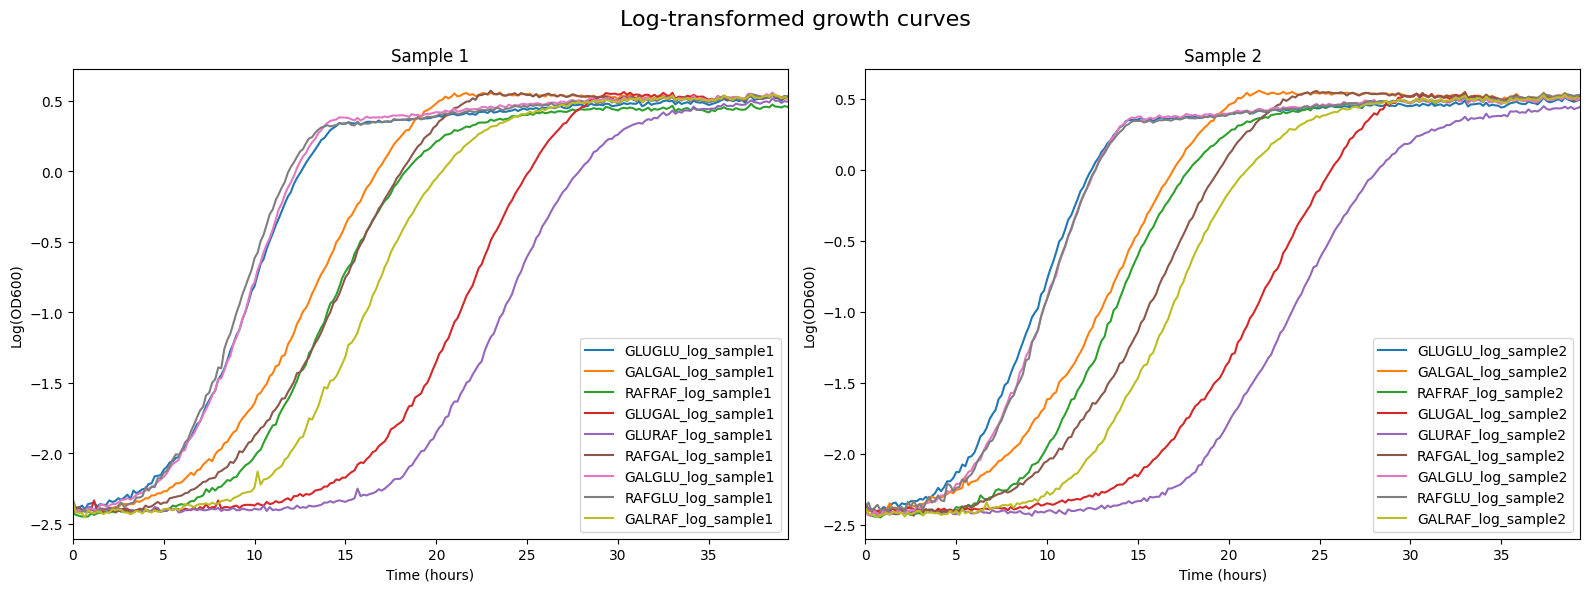

In [10]:
# Step 1: time_in_hours is already created in df_transformed during transformation

# Step 2: Plot all conditions for Sample1 and Sample2
# Sample 1 conditions: Collect all columns ending in '_log_sample1'
sample1_columns = [col for col in df_transformed.columns if col.endswith('_log_sample1')]
# Sample 2 conditions: Collect all columns ending in '_log_sample2'
sample2_columns = [col for col in df_transformed.columns if col.endswith('_log_sample2')]

# Plot setup. Initialise a plot containing two subplots: one for Sample1, one for Sample2:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Step 3: Plot all Sample 1 conditions on the first subplot
for condition in sample1_columns:
    ax1.plot(df_transformed['time_in_hours'], df_transformed[condition], label=condition)

# Set y-axis and x-axis limits for Sample 1 plot
ax1.set_xlabel("Time (hours)")
ax1.set_ylabel("Log(OD600)")
ax1.set_title("Sample 1")
ax1.legend()
ax1.set_xlim(0, df_transformed['time_in_hours'].max())

# Step 4:  Plot all Sample 2 conditions on the second subplot
for condition in sample2_columns:
    ax2.plot(df_transformed['time_in_hours'], df_transformed[condition], label=condition)

# Set y-axis and x-axis limits for Sample 2 plot
ax2.set_xlabel("Time (hours)")
ax2.set_ylabel("Log(OD600)")
ax2.set_title("Sample 2")
ax2.legend()
ax2.set_xlim(0, df_transformed['time_in_hours'].max())

# Set the overall title
fig.suptitle("Log-transformed growth curves", fontsize=16)

plt.tight_layout()
plt.show()

- How are the plots changed after log transformation?

- Why do we log transform the data?

In [11]:
# save the plot
fig.savefig("test.png", dpi=300)

Next we will apply a smoothing function to our logged transformed growth data.

for more information on the function parameters see: # added 

In [12]:
# SAVITZKY-GOLAY FILTER APPLICATION 
from scipy.signal import savgol_filter
savgol_filter?

Signature:
savgol_filter(
    x,
    window_length,
    polyorder,
    deriv=0,
    delta=1.0,
    axis=-1,
    mode='interp',
    cval=0.0,
)
Docstring:
Apply a Savitzky-Golay filter to an array.

This is a 1-D filter. If `x`  has dimension greater than 1, `axis`
determines the axis along which the filter is applied.

Parameters
----------
x : array_like
    The data to be filtered. If `x` is not a single or double precision
    floating point array, it will be converted to type ``numpy.float64``
    before filtering.
window_length : int
    The length of the filter window (i.e., the number of coefficients).
    If `mode` is 'interp', `window_length` must be less than or equal
    to the size of `x`.
polyorder : int
    The order of the polynomial used to fit the samples.
    `polyorder` must be less than `window_length`.
deriv : int, optional
    The order of the derivative to compute. This must be a
    nonnegative integer. The default is 0, which means to filter
    the data withou

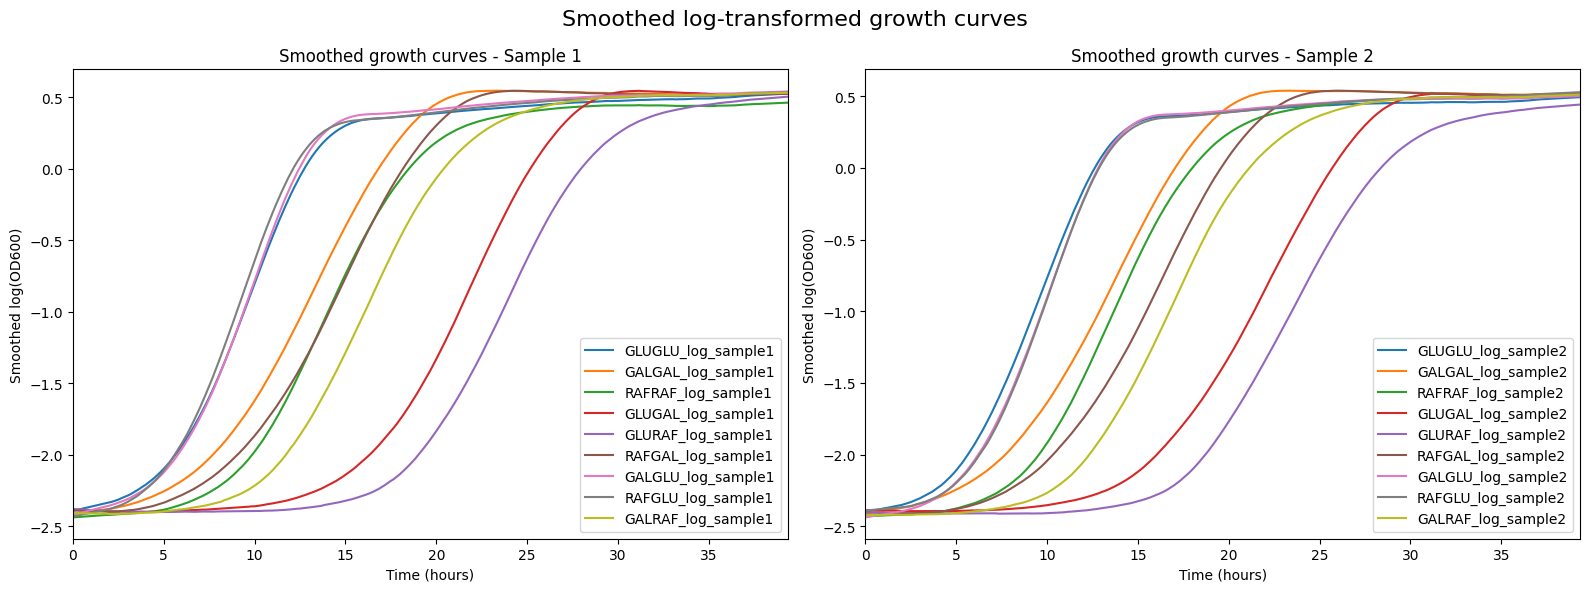

In [13]:
df_filtered = df_transformed.copy()  # create a copy to store filtered data

# Smooth only signal columns; keep time column untouched
signal_cols = [col for col in df_filtered.columns if col.endswith('_log_sample1') or col.endswith('_log_sample2')]

for col in signal_cols:
    series = pd.to_numeric(df_filtered[col], errors='coerce')

    # Fill small gaps before smoothing
    series_filled = series.interpolate(limit_direction='both')

    # Ensure valid odd window length for current series size
    n = len(series_filled)
    wl = min(24, n if n % 2 == 1 else n - 1)
    if wl < 3:
        wl = 3
    if wl % 2 == 0:
        wl -= 1

    df_filtered[col] = savgol_filter(series_filled.to_numpy(), window_length=wl, polyorder=1)

# Your code here plot the smoothed curves ######################################################### #
# Collect sample 1 and sample 2 columns
sample1_columns = [col for col in df_filtered.columns if col.endswith("_log_sample1")]
sample2_columns = [col for col in df_filtered.columns if col.endswith("_log_sample2")]

# Create two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot smoothed Sample 1 curves
for condition in sample1_columns:
    ax1.plot(
        df_filtered["time_in_hours"],
        df_filtered[condition],
        label=condition
    )

ax1.set_xlabel("Time (hours)")
ax1.set_ylabel("Smoothed log(OD600)")
ax1.set_title("Smoothed growth curves - Sample 1")
ax1.legend()
ax1.set_xlim(0, df_filtered["time_in_hours"].max())

# Plot smoothed Sample 2 curves
for condition in sample2_columns:
    ax2.plot(
        df_filtered["time_in_hours"],
        df_filtered[condition],
        label=condition
    )

ax2.set_xlabel("Time (hours)")
ax2.set_ylabel("Smoothed log(OD600)")
ax2.set_title("Smoothed growth curves - Sample 2")
ax2.legend()
ax2.set_xlim(0, df_filtered["time_in_hours"].max())

# Overall title
fig.suptitle("Smoothed log-transformed growth curves", fontsize=16)

plt.tight_layout()
plt.show()

###################################################################################################

- If the data was not smoothed, how could this affect the determination of the maximal growth rate?

Now we will extract the maximal growth rates and the lagphase from each growth curve. We will need several functions to do this, which are all detailed below.

FUNCTIONS NEEDED FOR MAXIMAL GROWTH RATE AND LAG PHASE DETECTION 

In [14]:
# linear function to fit
def linear_func(x, mu, c):
    return mu * x + c

# to extract mu, tlag and save processed values into dataframes
def extract_mu_and_tlag(df, col_name):
    # Reset index for safety
    df = df.reset_index(drop=True)

    # Convert to numeric and keep track of finite values
    y_all = pd.to_numeric(df[col_name], errors="coerce").to_numpy(dtype=float)
    valid_mask = np.isfinite(y_all)
    valid_idx = np.where(valid_mask)[0]

    # Default outputs for robustness
    growth_rate_all = np.full(len(df), np.nan)
    fitted_all = np.full(len(df), np.nan)

    # If too few valid points exist, return NaNs directly
    if valid_mask.sum() < 5:
        output_aggregate = {
            "max_growth_rate_index": [np.nan],
            "start_index": [np.nan],
            "end_index": [np.nan],
            "ws": [np.nan],
            "mu": [np.nan],
            "tlag": [np.nan],
            "tzero": [np.nan],
            "c": [np.nan],
        }
        output_raw_data = {
            "smoothed_values": y_all,
            "growth_rate": growth_rate_all,
            "fitted_linear_curve": fitted_all,
            "cycles": df.index.values,
            "time_hours": df["time_in_hours"],
        }
        return pd.DataFrame(output_aggregate), pd.DataFrame(output_raw_data)

    # Derivative only on valid points, then map back to full-length vector
    growth_rate_valid = np.gradient(y_all[valid_mask])
    growth_rate_all[valid_idx] = growth_rate_valid * 6

    # Find index of maximum growth rate among valid points
    local_max_idx = int(np.nanargmax(growth_rate_valid))
    max_growth_rate_index = int(valid_idx[local_max_idx])
    growth_rate_max = float(np.nanmax(growth_rate_valid))

    # Compute window size (ws) robustly
    if not np.isfinite(growth_rate_max) or growth_rate_max <= 0:
        ws = 3
    else:
        ws = max(3, int(round(np.log(2) / growth_rate_max)))

    # Ensure the indices are within bounds
    start_index = max(0, max_growth_rate_index - ws)
    end_index = min(len(df) - 1, max_growth_rate_index + ws)

    # Select window around max growth rate and keep only finite points for fitting
    x_win = df.index[start_index : end_index + 1].to_numpy(dtype=float)
    y_win = y_all[start_index : end_index + 1]
    fit_mask = np.isfinite(x_win) & np.isfinite(y_win)

    # Fit a linear curve to the selected region
    if fit_mask.sum() < 3:
        mu, c = np.nan, np.nan
    else:
        try:
            popt, _ = curve_fit(linear_func, x_win[fit_mask], y_win[fit_mask])
            mu, c = popt
        except Exception:
            mu, c = np.nan, np.nan

    # Calculate t0 from first finite points instead of first rows
    first_finite = y_all[np.isfinite(y_all)][:3]
    if len(first_finite) < 3:
        t0 = np.nan
    else:
        t0 = float(np.mean(first_finite))

    # Extract lag phase safely
    if (not np.isfinite(mu)) or mu == 0 or (not np.isfinite(t0)) or (not np.isfinite(c)):
        tlag = np.nan
    else:
        tlag = (t0 - c) / mu

    # Full fitted curve (or NaNs if fit failed)
    if np.isfinite(mu) and np.isfinite(c):
        fitted_all = linear_func(df.index.to_numpy(dtype=float), mu, c)

    # Prepare output
    output_aggregate = {
        "max_growth_rate_index": [max_growth_rate_index],
        "start_index": [start_index],
        "end_index": [end_index],
        "ws": [ws],
        "mu": [mu * 6 if np.isfinite(mu) else np.nan],
        "tlag": [tlag * 0.1666 if np.isfinite(tlag) else np.nan],  # tlag in hours
        "tzero": [t0],
        "c": [c],
    }
    output_raw_data = {
        "smoothed_values": y_all,
        "growth_rate": growth_rate_all,
        "fitted_linear_curve": fitted_all,
        "cycles": df.index.values,  # every cycle is 10 min
        "time_hours": df["time_in_hours"],
    }

    return pd.DataFrame(output_aggregate), pd.DataFrame(output_raw_data)

- Where in the code is written over which area the linear curve is fitted?

In [15]:
# APPLY THE FUNCTIONS TO THE DF_FILTERED DATAFRAME
results = []
results_raw = []

# List of columns to process (exclude 'time_in_hours')
columns_to_process = [col for col in df_filtered.columns if "_log_sample" in col]

print("Columns to process:")
print(columns_to_process)
print(f"Total columns to process: {len(columns_to_process)}")

# Apply the function for each column
for col in columns_to_process:
    non_finite_count = (~np.isfinite(pd.to_numeric(df_filtered[col], errors="coerce"))).sum()
    print(f"\nProcessing {col} | non-finite points: {non_finite_count}")

    col_results, col_results_raw = extract_mu_and_tlag(df_filtered, col)

    print(
        f"  mu={col_results['mu'].iloc[0]} | tlag={col_results['tlag'].iloc[0]} | "
        f"start={col_results['start_index'].iloc[0]} end={col_results['end_index'].iloc[0]} ws={col_results['ws'].iloc[0]}"
    )

    col_results['column'] = col  # Store the column name for identification
    col_results_raw['column'] = col
    results.append(col_results)
    results_raw.append(col_results_raw)

# Combine all results into a single DataFrame
final_results = pd.concat(results).reset_index(drop=True)
final_results_raw = pd.concat(results_raw).reset_index(drop=True)

print("\n--- Extraction summary ---")
print(f"Rows in final_results: {len(final_results)}")
print(f"mu NaN count: {final_results['mu'].isna().sum()} / {len(final_results)}")
print(f"tlag NaN count: {final_results['tlag'].isna().sum()} / {len(final_results)}")
print("Rows with NaN tlag:")
print(final_results.loc[final_results['tlag'].isna(), ['column', 'mu', 'tlag', 'start_index', 'end_index', 'ws']])

# Show the first few rows of the final results to inspect
final_results

# You can also have a look at the final_results raw table
final_results_raw

# Save extracted data to a single fixed filename
out_file = 'growth_rate_lagphase_results.csv'
try:
    final_results.to_csv(out_file, index=False)
    print(f"Saved: {out_file}")
except PermissionError:
    print(f"Could not save {out_file} because it is open/locked. Close the file and rerun this cell.")

Columns to process:
['GLUGLU_log_sample1', 'GLUGLU_log_sample2', 'GALGAL_log_sample1', 'GALGAL_log_sample2', 'RAFRAF_log_sample1', 'RAFRAF_log_sample2', 'GLUGAL_log_sample1', 'GLUGAL_log_sample2', 'GLURAF_log_sample1', 'GLURAF_log_sample2', 'RAFGAL_log_sample1', 'RAFGAL_log_sample2', 'GALGLU_log_sample1', 'GALGLU_log_sample2', 'RAFGLU_log_sample1', 'RAFGLU_log_sample2', 'GALRAF_log_sample1', 'GALRAF_log_sample2']
Total columns to process: 18

Processing GLUGLU_log_sample1 | non-finite points: 0
  mu=0.32819114564418994 | tlag=5.175220741676202 | start=46 end=70 ws=12

Processing GLUGLU_log_sample2 | non-finite points: 0
  mu=0.32171018994330325 | tlag=4.945949250008605 | start=47 end=71 ws=12

Processing GALGAL_log_sample1 | non-finite points: 0
  mu=0.2508727534074537 | tlag=7.018762946601327 | start=63 end=95 ws=16

Processing GALGAL_log_sample2 | non-finite points: 0
  mu=0.2471467049119003 | tlag=7.141290796937099 | start=66 end=98 ws=16

Processing RAFRAF_log_sample1 | non-finite 

We can also visualize the extraction of lagphases and growth rates by plotting the values in the final results raw dataframe.

(-3.0, 0.8)

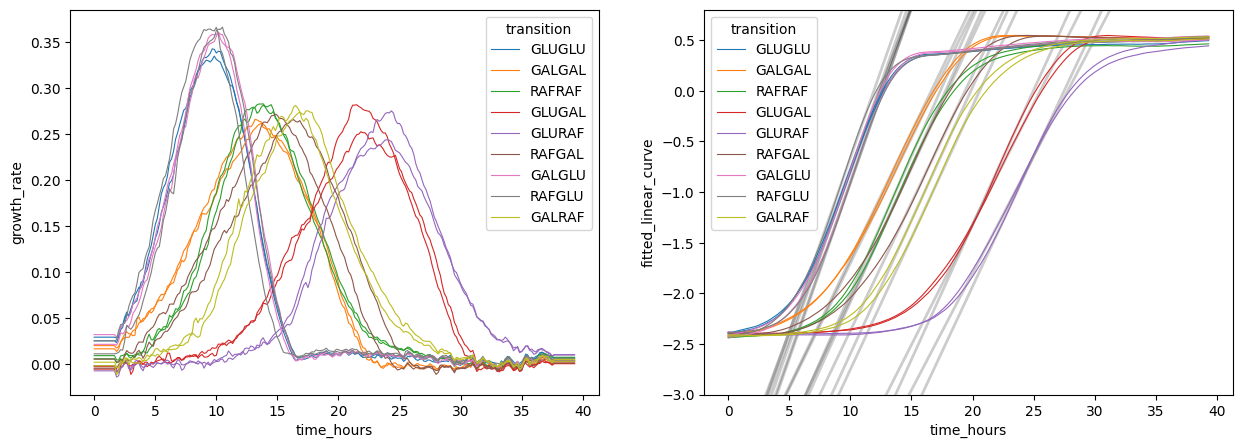

In [16]:
#add column as hue for seaborn
final_results_raw['transition'] = final_results_raw['column'].str.split('_',expand=True)[0]

fix,ax= plt.subplots(ncols=2, figsize=(15,5))

sns.lineplot(final_results_raw,y='growth_rate',x='time_hours', hue='transition', units='column',estimator=None,linewidth=.8,ax=ax[0])

sns.lineplot(final_results_raw,y='fitted_linear_curve',x='time_hours',color='black', units='column',estimator=None,linewidth=2,ax=ax[1],alpha=0.2)
sns.lineplot(final_results_raw,y='smoothed_values',x='time_hours', hue='transition', units='column',estimator=None,linewidth=.8,ax=ax[1])
ax[1].set_ylim(-3,.8)

- Go back to the function "extract_mu_and_tlag". Do you understand how the linear curve and the Tzero are used to determine the lagphase? 

***

- In the last part we extracted the growth rates and lagphase of the different strains. Now, we want to plot the differences in lag phases and growh rates. This part you will code yourself! Closely, inspect the plots you have created. What conclusions can be drawn? 

--- Plot input checks ---
Rows in plot_df: 18
Unique conditions: 9
mu NaN count: 0 / 18
tlag NaN count: 0 / 18
                column condition   sample        mu       tlag
0   GLUGLU_log_sample1    GLUGLU  sample1  0.328191   5.175221
1   GLUGLU_log_sample2    GLUGLU  sample2  0.321710   4.945949
2   GALGAL_log_sample1    GALGAL  sample1  0.250873   7.018763
3   GALGAL_log_sample2    GALGAL  sample2  0.247147   7.141291
4   RAFRAF_log_sample1    RAFRAF  sample1  0.267444   8.677686
5   RAFRAF_log_sample2    RAFRAF  sample2  0.271671   8.422480
6   GLUGAL_log_sample1    GLUGAL  sample1  0.265719  15.996179
7   GLUGAL_log_sample2    GLUGAL  sample2  0.237726  15.500751
8   GLURAF_log_sample1    GLURAF  sample1  0.257510  18.250928
9   GLURAF_log_sample2    GLURAF  sample2  0.230722  17.383392
10  RAFGAL_log_sample1    RAFGAL  sample1  0.258031   8.691447
11  RAFGAL_log_sample2    RAFGAL  sample2  0.252020   9.790689
12  GALGLU_log_sample1    GALGLU  sample1  0.343611   5.259602
13  GAL

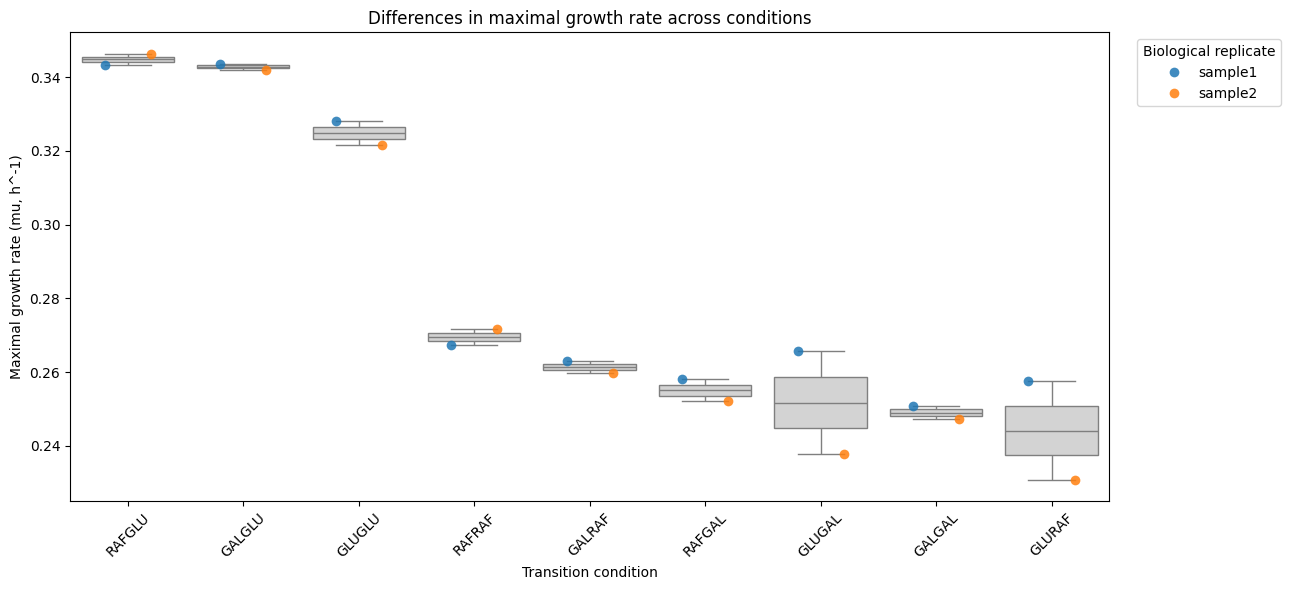

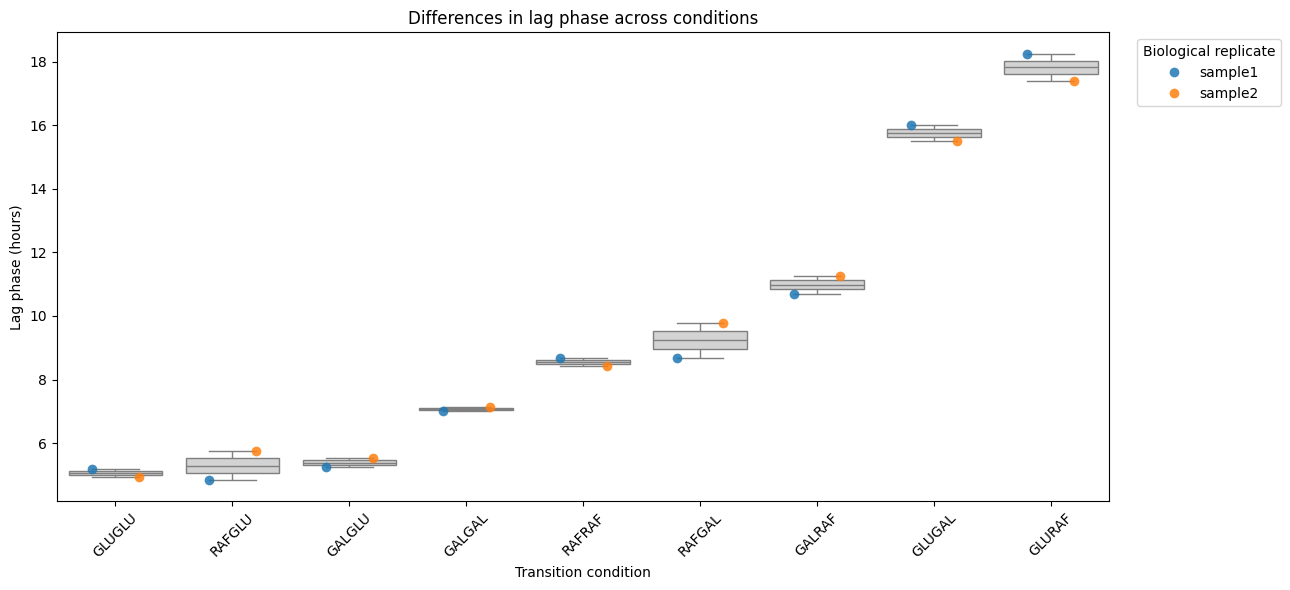

,mu_median,tlag_median
condition,,
RAFGLU,0.344832,5.291889
GALGLU,0.342858,5.389430
GLUGLU,0.324951,5.060585
RAFRAF,0.269557,8.550083
GALRAF,0.261376,10.979963
RAFGAL,0.255026,9.241068
GLUGAL,0.251722,15.748465
GALGAL,0.249010,7.080027
GLURAF,0.244116,17.817160


In [17]:
# Compare maximal growth rate (mu) and lag phase (tlag) across transitions
# This is the summary view expected in the practical.

plot_df = final_results.copy()

# Parse transition and replicate from the processed column names
plot_df["condition"] = (
    plot_df["column"]
    .str.replace("_log_sample1", "", regex=False)
    .str.replace("_log_sample2", "", regex=False)
)
plot_df["sample"] = plot_df["column"].str.extract(r"(sample\d+)")

# Ensure numeric values
plot_df["mu"] = pd.to_numeric(plot_df["mu"], errors="coerce")
plot_df["tlag"] = pd.to_numeric(plot_df["tlag"], errors="coerce")

print("--- Plot input checks ---")
print(f"Rows in plot_df: {len(plot_df)}")
print(f"Unique conditions: {plot_df['condition'].nunique(dropna=True)}")
print(f"mu NaN count: {plot_df['mu'].isna().sum()} / {len(plot_df)}")
print(f"tlag NaN count: {plot_df['tlag'].isna().sum()} / {len(plot_df)}")
print(plot_df[["column", "condition", "sample", "mu", "tlag"]])

# Keep only rows with valid comparison values
plot_mu_df = plot_df.dropna(subset=["condition", "sample", "mu"]).copy()
plot_tlag_df = plot_df.dropna(subset=["condition", "sample", "tlag"]).copy()

print("\nRows used for mu plot:", len(plot_mu_df))
print("Rows used for tlag plot:", len(plot_tlag_df))
if not plot_tlag_df.empty:
    print("tlag summary:")
    print(plot_tlag_df["tlag"].describe())

if plot_mu_df.empty:
    print("No valid mu values to plot.")
else:
    # Order conditions by median mu to make differences easier to see
    condition_order_mu = (
        plot_mu_df.groupby("condition")["mu"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(13, 6))
    sns.boxplot(
        data=plot_mu_df,
        x="condition",
        y="mu",
        order=condition_order_mu,
        color="lightgray",
        fliersize=0
    )
    sns.stripplot(
        data=plot_mu_df,
        x="condition",
        y="mu",
        hue="sample",
        order=condition_order_mu,
        dodge=True,
        alpha=0.85,
        size=7
    )
    plt.xlabel("Transition condition")
    plt.ylabel("Maximal growth rate (mu, h^-1)")
    plt.title("Differences in maximal growth rate across conditions")
    plt.xticks(rotation=45)
    plt.legend(title="Biological replicate", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

if plot_tlag_df.empty:
    print("No valid tlag values to plot.")
else:
    # Order conditions by median lag phase (shortest to longest)
    condition_order_tlag = (
        plot_tlag_df.groupby("condition")["tlag"]
        .median()
        .sort_values(ascending=True)
        .index
    )

    plt.figure(figsize=(13, 6))
    sns.boxplot(
        data=plot_tlag_df,
        x="condition",
        y="tlag",
        order=condition_order_tlag,
        color="lightgray",
        fliersize=0
    )
    sns.stripplot(
        data=plot_tlag_df,
        x="condition",
        y="tlag",
        hue="sample",
        order=condition_order_tlag,
        dodge=True,
        alpha=0.85,
        size=7
    )
    plt.xlabel("Transition condition")
    plt.ylabel("Lag phase (hours)")
    plt.title("Differences in lag phase across conditions")
    plt.xticks(rotation=45)
    plt.legend(title="Biological replicate", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# Optional: show compact summary table
summary = (
    plot_df.groupby("condition", dropna=True)
    .agg(mu_median=("mu", "median"), tlag_median=("tlag", "median"))
    .sort_values("mu_median", ascending=False)
)
summary

- Did you note that you so far only extracted the growth rates and lagphases of a single strain? Complete the same extraction for the other strains as well and make sure to compare the extracted data for all strains and transitions as well. Again it is your turn to code.

Found 7 workbook(s)
Plate Reader Data\YET784_DATA_1312.xlsx
Plate Reader Data\YET858_DATA_2305.xlsx
Plate Reader Data\YET911_DATA_2401.xlsx
Plate Reader Data\YET937_DATA_2401.xlsx
Plate Reader Data\YET938_DATA_2701.xlsx
Plate Reader Data\YET962_DATA_2901.xlsx
Plate Reader Data\YET963_DATA_2901.xlsx
Saved growth_rate_lagphase_YET784.csv (18 rows)
Saved growth_rate_lagphase_YET858.csv (18 rows)
Saved growth_rate_lagphase_YET911.csv (18 rows)
Saved growth_rate_lagphase_YET937.csv (18 rows)
Saved growth_rate_lagphase_YET938.csv (18 rows)
Saved growth_rate_lagphase_YET962.csv (18 rows)
Saved growth_rate_lagphase_YET963.csv (18 rows)
Saved growth_rate_lagphase_all_strains.csv
Saved growth_rate_lagphase_all_strains_raw.csv

Rows for mu plots: 126
Rows for tlag plots: 126


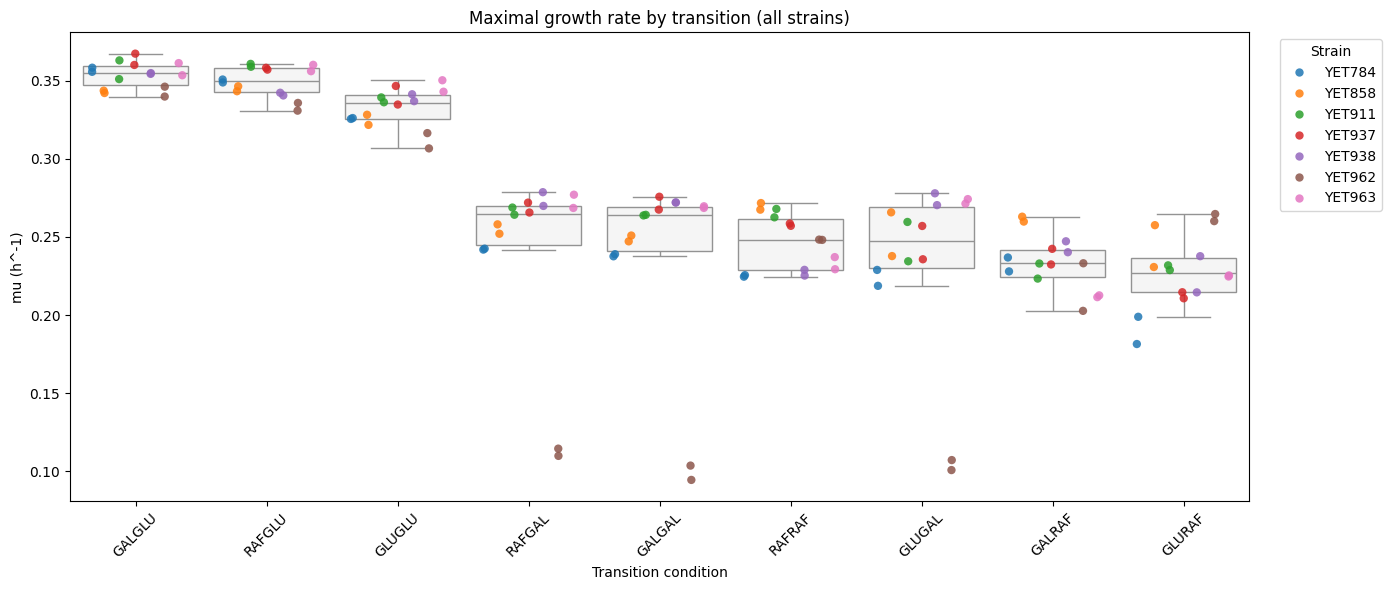

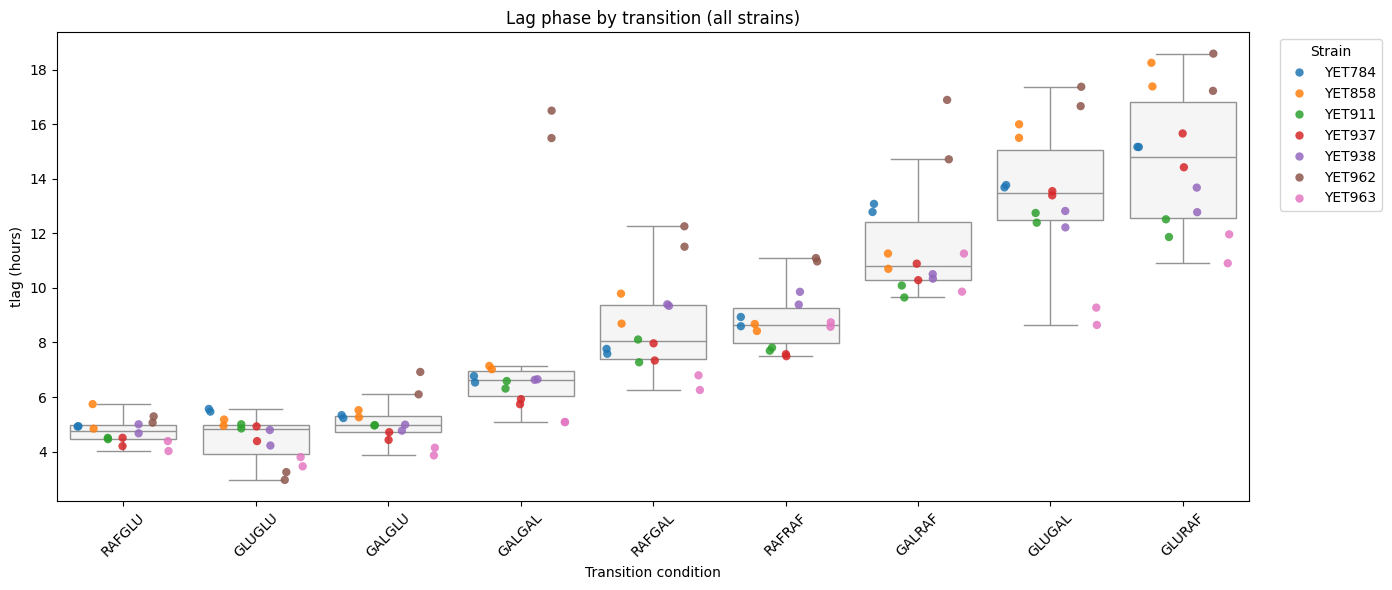

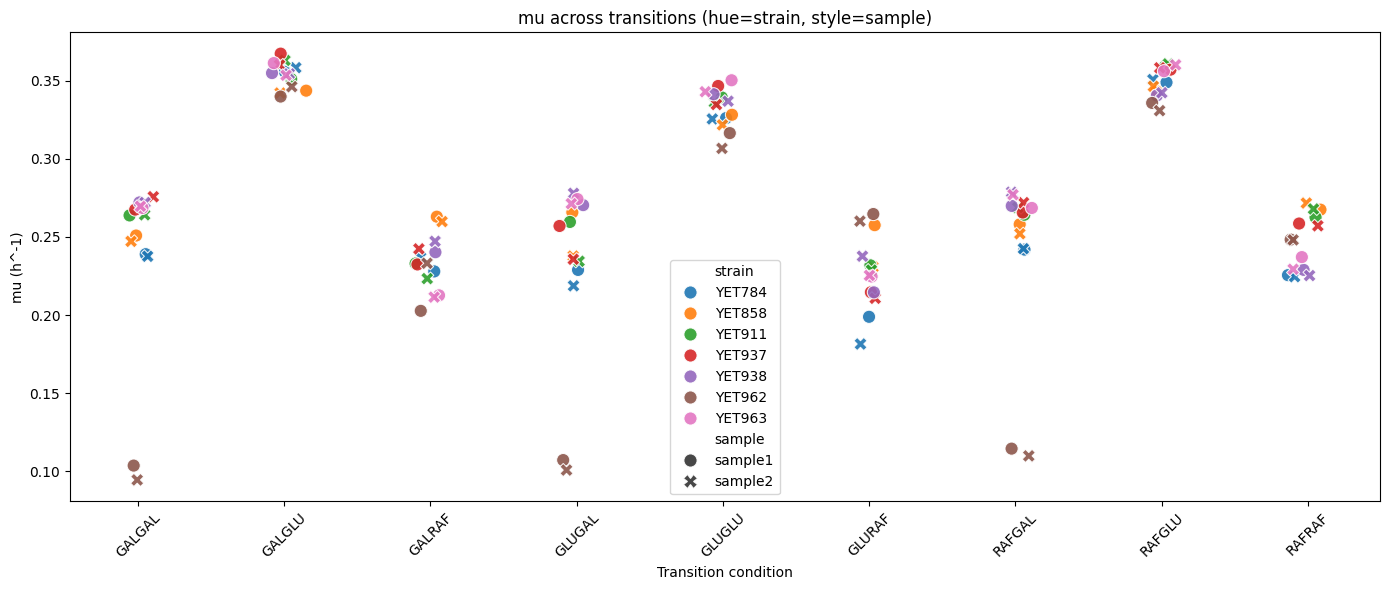

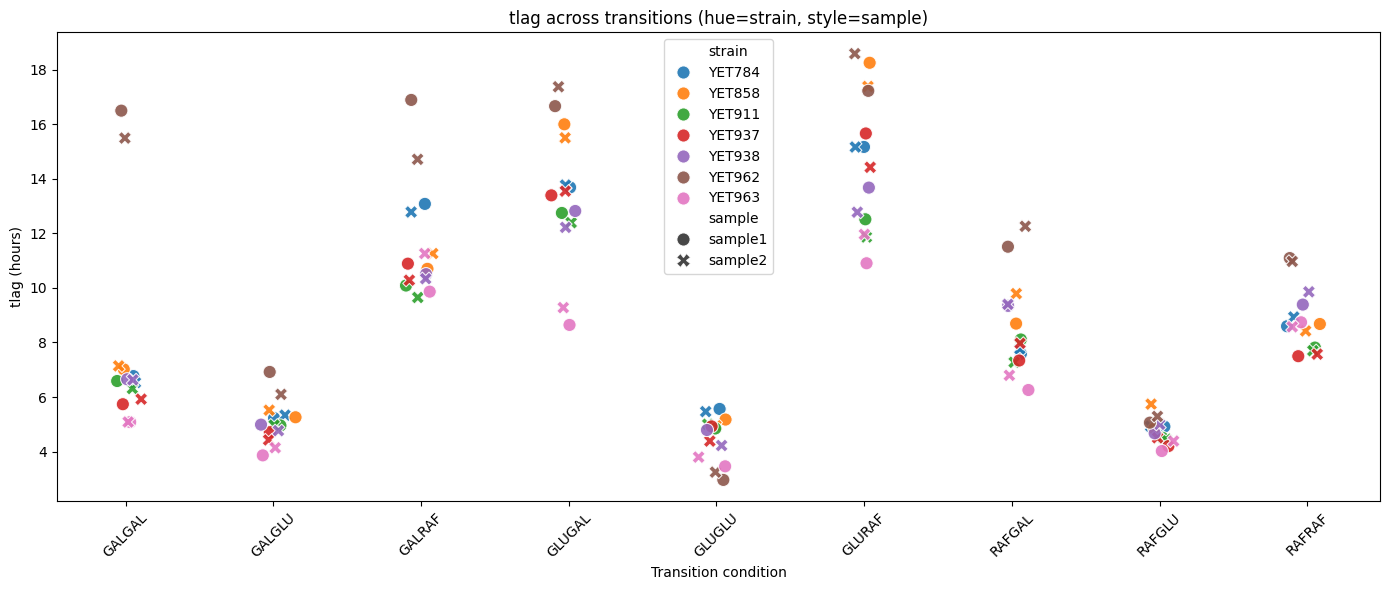

,strain,condition,mu_median,tlag_median
36,YET938,GALGAL,0.272040,6.641696
27,YET937,GALGAL,0.271595,5.830586
54,YET963,GALGAL,0.269078,5.084226
18,YET911,GALGAL,0.263939,6.449767
9,YET858,GALGAL,0.249010,7.080027
...,...,...,...,...
35,YET937,RAFRAF,0.257822,7.535277
53,YET962,RAFRAF,0.248176,11.032664
62,YET963,RAFRAF,0.233186,8.657508
44,YET938,RAFRAF,0.227077,9.622972


In [18]:
# Process all strain files, save per-strain + combined CSVs, and compare all strains/transitions
excel_files = sorted(glob(r"Plate Reader Data\\*.xlsx"))
print(f"Found {len(excel_files)} workbook(s)")
print("\n".join(excel_files))

# Reuse the same transition-to-well mapping defined earlier in the notebook
conditions_map = conditions.copy()

def process_single_workbook(file_path, conditions_map):
    """Run the same processing pipeline for one workbook and return aggregate + raw extraction tables."""
    # ---------- Load and clean ----------
    df = pd.read_excel(file_path, sheet_name="Table All Cycles")
    df_cleaned = df.copy()
    df_cleaned.columns = df_cleaned.iloc[11]
    df_cleaned = df_cleaned.iloc[12:].reset_index(drop=True)
    if "Well" in df_cleaned.columns:
        df_cleaned = df_cleaned.drop(columns=["Well"])
    df_cleaned = df_cleaned.rename(columns={df_cleaned.columns[0]: "Time"})

    # Parse time columns
    df_cleaned["time_minutes"] = (
        df_cleaned["Time"].astype(str).str.extract(r"(\d+)\s*min").fillna(0).astype(int)
    )
    df_cleaned["time_hours"] = (
        df_cleaned["Time"].astype(str).str.extract(r"(\d+)\s*h").fillna(0).astype(int)
    )

    # ---------- Rename wells to condition-replicate labels ----------
    rename_dict = {}
    for condition, wells in conditions_map.items():
        if len(wells) < 4:
            continue
        rename_dict.update({
            wells[0]: f"{condition}1",
            wells[1]: f"{condition}1",
            wells[2]: f"{condition}2",
            wells[3]: f"{condition}2",
        })

    df_renamed_local = df_cleaned.rename(columns=rename_dict)

    # ---------- Build transformed table (same logic as earlier cells) ----------
    conditions_samples_local = {
        cond: [f"{cond}1", f"{cond}1", f"{cond}2", f"{cond}2"]
        for cond in conditions_map.keys()
    }

    df_transformed_local = pd.DataFrame()
    for condition, samples in conditions_samples_local.items():
        sample1, sample2, sample3, sample4 = samples
        required_cols = ["time_hours", "time_minutes", sample1, sample2, sample3, sample4]

        # Skip condition if required columns are missing in this file
        if not all(col in df_renamed_local.columns for col in required_cols):
            continue

        sample_data = df_renamed_local[required_cols].copy()
        sample_data = sample_data.apply(pd.to_numeric, errors="coerce")
        sample_data["mean_sample1_sample2"] = sample_data[[sample1, sample2]].mean(axis=1)
        sample_data["mean_sample3_sample4"] = sample_data[[sample3, sample4]].mean(axis=1)
        sample_data["mean_sample1_sample2"] = sample_data["mean_sample1_sample2"].clip(lower=1e-6)
        sample_data["mean_sample3_sample4"] = sample_data["mean_sample3_sample4"].clip(lower=1e-6)

        df_transformed_local[condition + "_log_sample1"] = np.log(sample_data["mean_sample1_sample2"])
        df_transformed_local[condition + "_log_sample2"] = np.log(sample_data["mean_sample3_sample4"])

    df_transformed_local["time_in_hours"] = (
        pd.to_numeric(df_renamed_local["time_hours"], errors="coerce")
        + pd.to_numeric(df_renamed_local["time_minutes"], errors="coerce") / 60
    )

    signal_cols_local = [
        c for c in df_transformed_local.columns
        if c.endswith("_log_sample1") or c.endswith("_log_sample2")
    ]
    if len(signal_cols_local) == 0:
        raise ValueError("No transformed signal columns were generated for this workbook.")

    finite_any = np.isfinite(df_transformed_local[signal_cols_local]).any(axis=1)
    df_transformed_local = df_transformed_local.loc[finite_any].reset_index(drop=True)

    # ---------- Smooth transformed signal ----------
    df_filtered_local = df_transformed_local.copy()
    for col in signal_cols_local:
        series = pd.to_numeric(df_filtered_local[col], errors="coerce")
        series_filled = series.interpolate(limit_direction="both")

        n = len(series_filled)
        wl = min(24, n if n % 2 == 1 else n - 1)
        if wl < 3:
            wl = 3
        if wl % 2 == 0:
            wl -= 1

        df_filtered_local[col] = savgol_filter(series_filled.to_numpy(), window_length=wl, polyorder=1)

    # ---------- Extract mu and tlag ----------
    results_local = []
    results_raw_local = []
    for col in [c for c in df_filtered_local.columns if "_log_sample" in c]:
        col_results, col_results_raw = extract_mu_and_tlag(df_filtered_local, col)
        col_results["column"] = col
        col_results_raw["column"] = col
        results_local.append(col_results)
        results_raw_local.append(col_results_raw)

    final_results_local = pd.concat(results_local).reset_index(drop=True)
    final_results_raw_local = pd.concat(results_raw_local).reset_index(drop=True)

    # Add metadata columns
    fname = Path(file_path).name
    strain_match = re.search(r"(YET\d+)", fname)
    strain = strain_match.group(1) if strain_match else Path(file_path).stem
    final_results_local["strain"] = strain
    final_results_local["source_file"] = fname
    final_results_raw_local["strain"] = strain
    final_results_raw_local["source_file"] = fname

    # Parse condition/sample for plotting convenience
    final_results_local["condition"] = (
        final_results_local["column"]
        .str.replace("_log_sample1", "", regex=False)
        .str.replace("_log_sample2", "", regex=False)
    )
    final_results_local["sample"] = final_results_local["column"].str.extract(r"(sample\d+)")

    return final_results_local, final_results_raw_local

# Run pipeline for all files
all_results = []
all_results_raw = []
failed_files = []

for fp in excel_files:
    try:
        fr, fr_raw = process_single_workbook(fp, conditions_map)
        all_results.append(fr)
        all_results_raw.append(fr_raw)

        strain_name = fr["strain"].iloc[0]
        out_name = f"growth_rate_lagphase_{strain_name}.csv"
        fr.to_csv(out_name, index=False)
        print(f"Saved {out_name} ({len(fr)} rows)")
    except Exception as e:
        failed_files.append((fp, str(e)))
        print(f"Failed on {fp}: {e}")

if len(all_results) == 0:
    raise ValueError("No files were processed successfully.")

all_strains_results = pd.concat(all_results, ignore_index=True)
all_strains_results_raw = pd.concat(all_results_raw, ignore_index=True)

all_strains_results.to_csv("growth_rate_lagphase_all_strains.csv", index=False)
all_strains_results_raw.to_csv("growth_rate_lagphase_all_strains_raw.csv", index=False)
print("Saved growth_rate_lagphase_all_strains.csv")
print("Saved growth_rate_lagphase_all_strains_raw.csv")

if failed_files:
    print("\nFiles with errors:")
    for f, msg in failed_files:
        print(f"- {f}: {msg}")

# -------------------- Plot summaries across all strains --------------------
plot_all = all_strains_results.copy()
plot_all["mu"] = pd.to_numeric(plot_all["mu"], errors="coerce")
plot_all["tlag"] = pd.to_numeric(plot_all["tlag"], errors="coerce")

mu_df = plot_all.dropna(subset=["condition", "strain", "sample", "mu"]).copy()
tlag_df = plot_all.dropna(subset=["condition", "strain", "sample", "tlag"]).copy()

print(f"\nRows for mu plots: {len(mu_df)}")
print(f"Rows for tlag plots: {len(tlag_df)}")

# 1) Box + strip plots (easy condition-wise comparison)
if not mu_df.empty:
    order_mu = mu_df.groupby("condition")["mu"].median().sort_values(ascending=False).index
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=mu_df, x="condition", y="mu", order=order_mu, color="whitesmoke", fliersize=0)
    sns.stripplot(data=mu_df, x="condition", y="mu", hue="strain", order=order_mu, dodge=True, alpha=0.85, size=6)
    plt.title("Maximal growth rate by transition (all strains)")
    plt.xlabel("Transition condition")
    plt.ylabel("mu (h^-1)")
    plt.xticks(rotation=45)
    plt.legend(title="Strain", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

if not tlag_df.empty:
    order_tlag = tlag_df.groupby("condition")["tlag"].median().sort_values().index
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=tlag_df, x="condition", y="tlag", order=order_tlag, color="whitesmoke", fliersize=0)
    sns.stripplot(data=tlag_df, x="condition", y="tlag", hue="strain", order=order_tlag, dodge=True, alpha=0.85, size=6)
    plt.title("Lag phase by transition (all strains)")
    plt.xlabel("Transition condition")
    plt.ylabel("tlag (hours)")
    plt.xticks(rotation=45)
    plt.legend(title="Strain", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# 2) Scatter plots using both hue and style (as requested)
if not mu_df.empty:
    condition_order = sorted(mu_df["condition"].unique())
    x_map = {c: i for i, c in enumerate(condition_order)}
    mu_df["x_num"] = mu_df["condition"].map(x_map).astype(float)
    rng = np.random.default_rng(42)
    mu_df["x_jitter"] = mu_df["x_num"] + rng.normal(0, 0.07, size=len(mu_df))

    plt.figure(figsize=(14, 6))
    sns.scatterplot(
        data=mu_df,
        x="x_jitter",
        y="mu",
        hue="strain",
        style="sample",
        s=90,
        alpha=0.9
    )
    plt.xticks(range(len(condition_order)), condition_order, rotation=45)
    plt.xlabel("Transition condition")
    plt.ylabel("mu (h^-1)")
    plt.title("mu across transitions (hue=strain, style=sample)")
    plt.tight_layout()
    plt.show()

if not tlag_df.empty:
    condition_order = sorted(tlag_df["condition"].unique())
    x_map = {c: i for i, c in enumerate(condition_order)}
    tlag_df["x_num"] = tlag_df["condition"].map(x_map).astype(float)
    rng = np.random.default_rng(42)
    tlag_df["x_jitter"] = tlag_df["x_num"] + rng.normal(0, 0.07, size=len(tlag_df))

    plt.figure(figsize=(14, 6))
    sns.scatterplot(
        data=tlag_df,
        x="x_jitter",
        y="tlag",
        hue="strain",
        style="sample",
        s=90,
        alpha=0.9
    )
    plt.xticks(range(len(condition_order)), condition_order, rotation=45)
    plt.xlabel("Transition condition")
    plt.ylabel("tlag (hours)")
    plt.title("tlag across transitions (hue=strain, style=sample)")
    plt.tight_layout()
    plt.show()

# 3) Compact summary table
summary_all = (
    plot_all.groupby(["strain", "condition"], dropna=True)
    .agg(mu_median=("mu", "median"), tlag_median=("tlag", "median"))
    .reset_index()
    .sort_values(["condition", "mu_median"], ascending=[True, False])
)

summary_all

mu rows for extra plots: 126
tlag rows for extra plots: 126


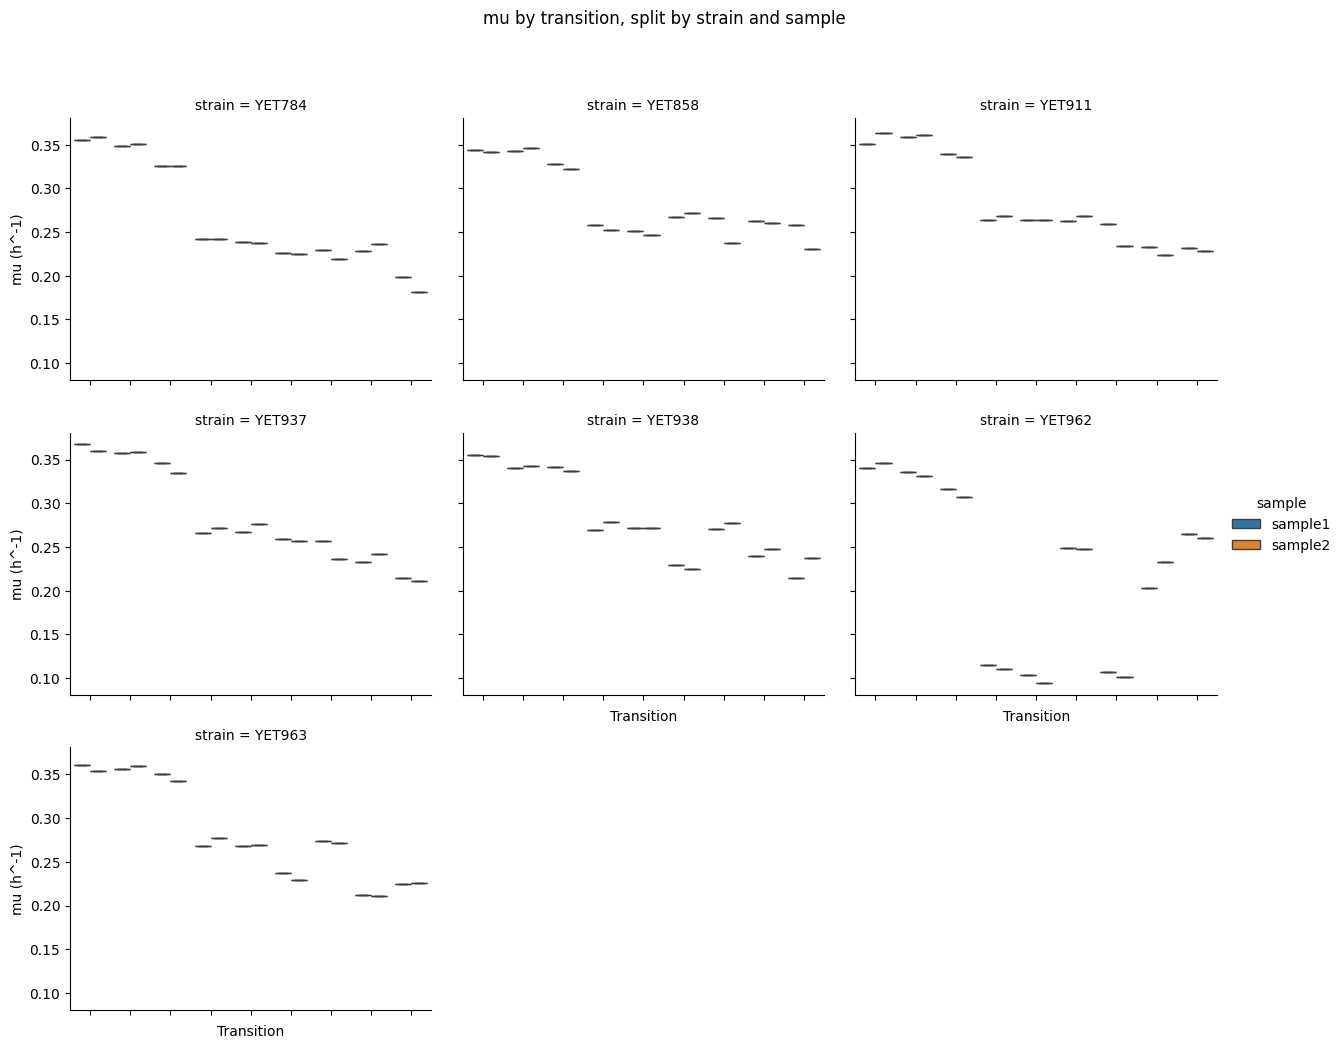

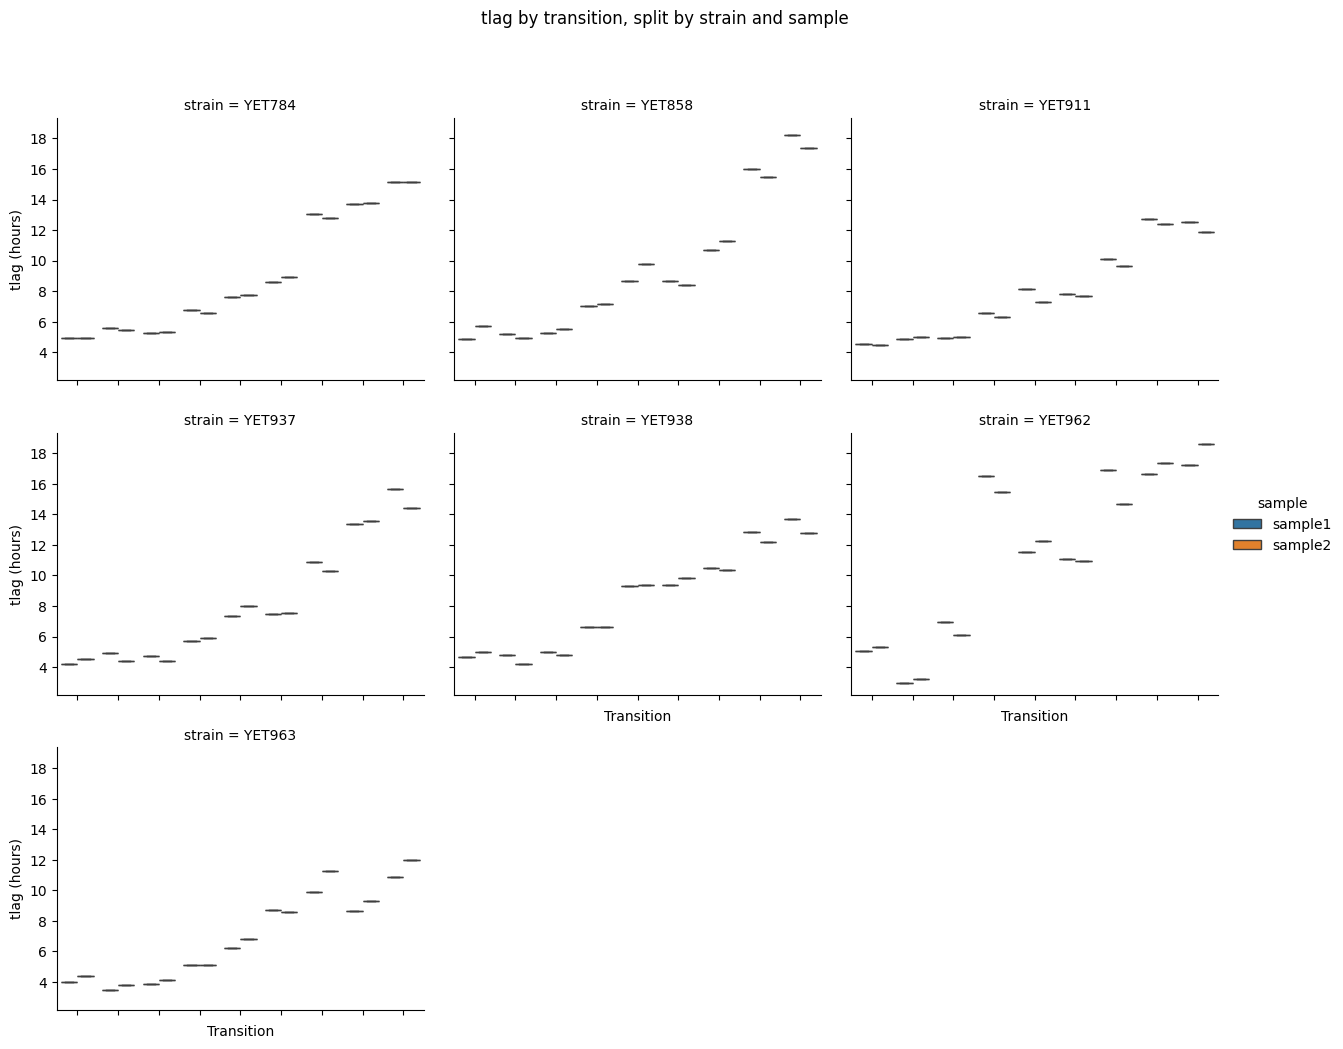

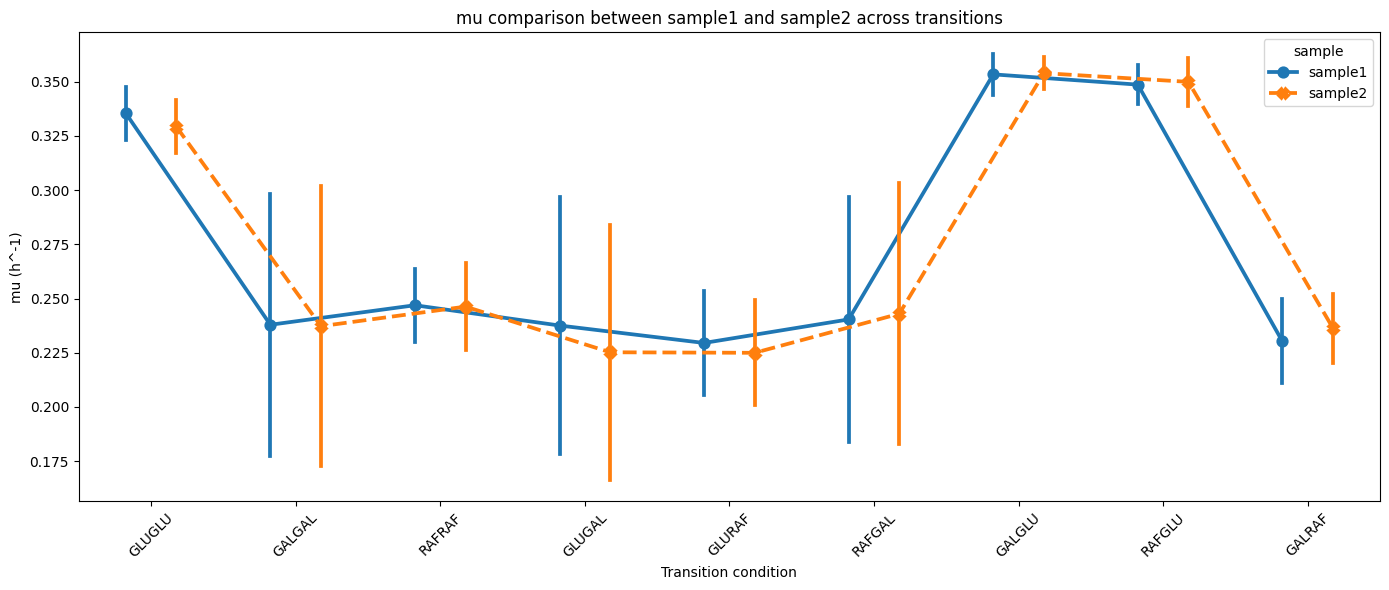

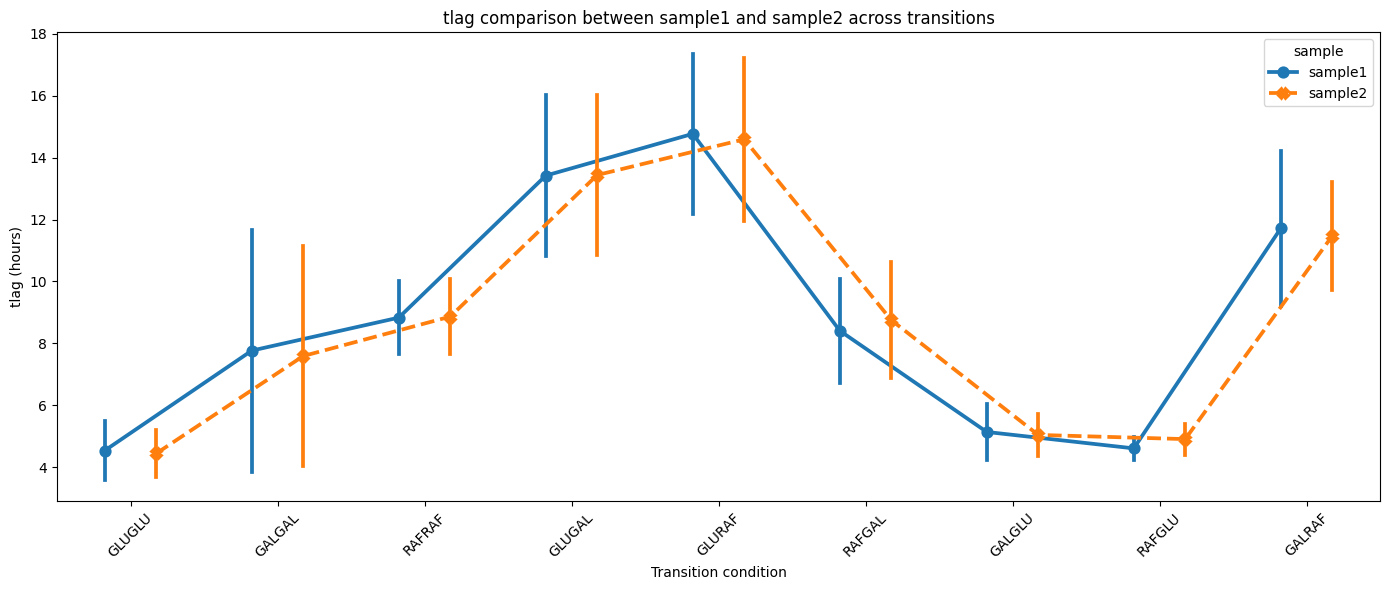

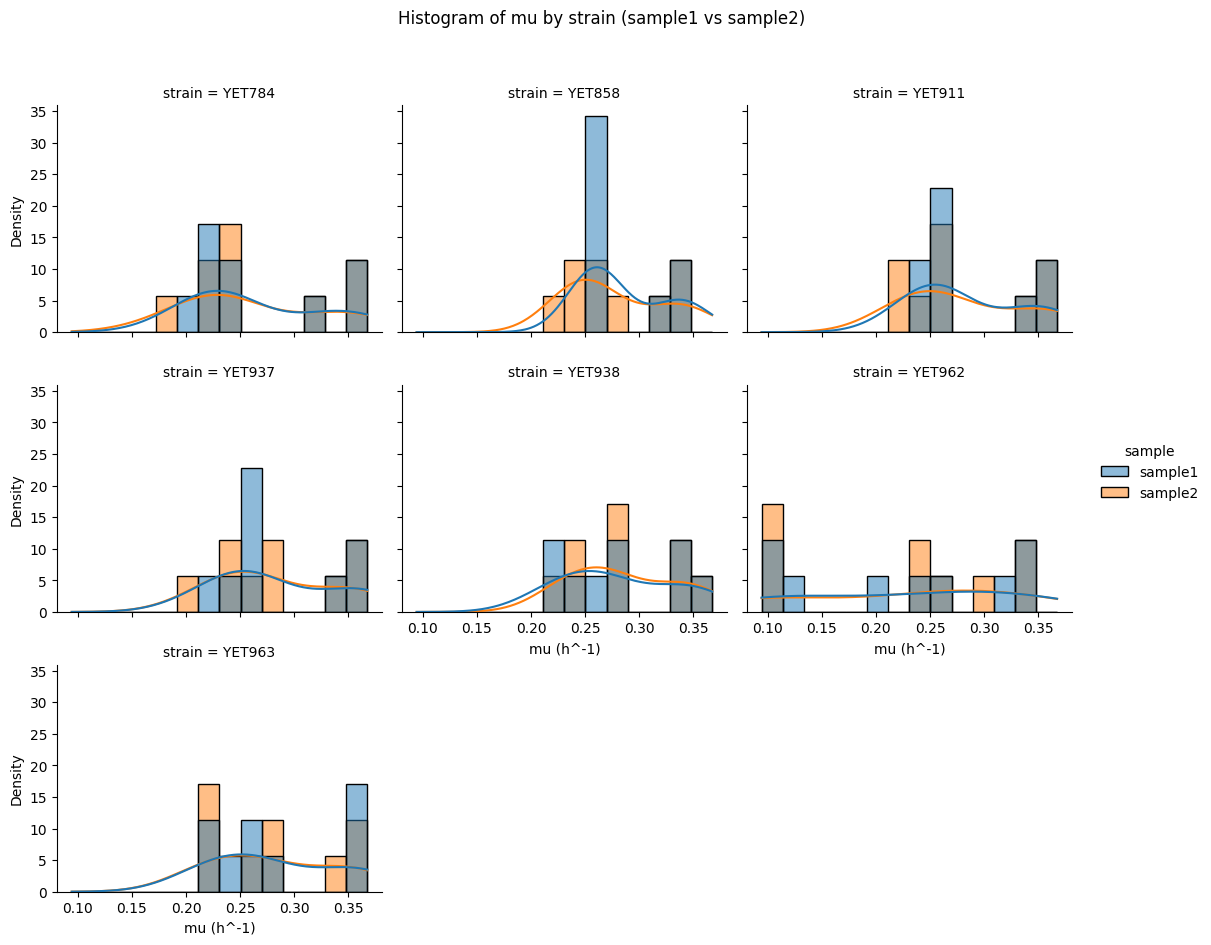

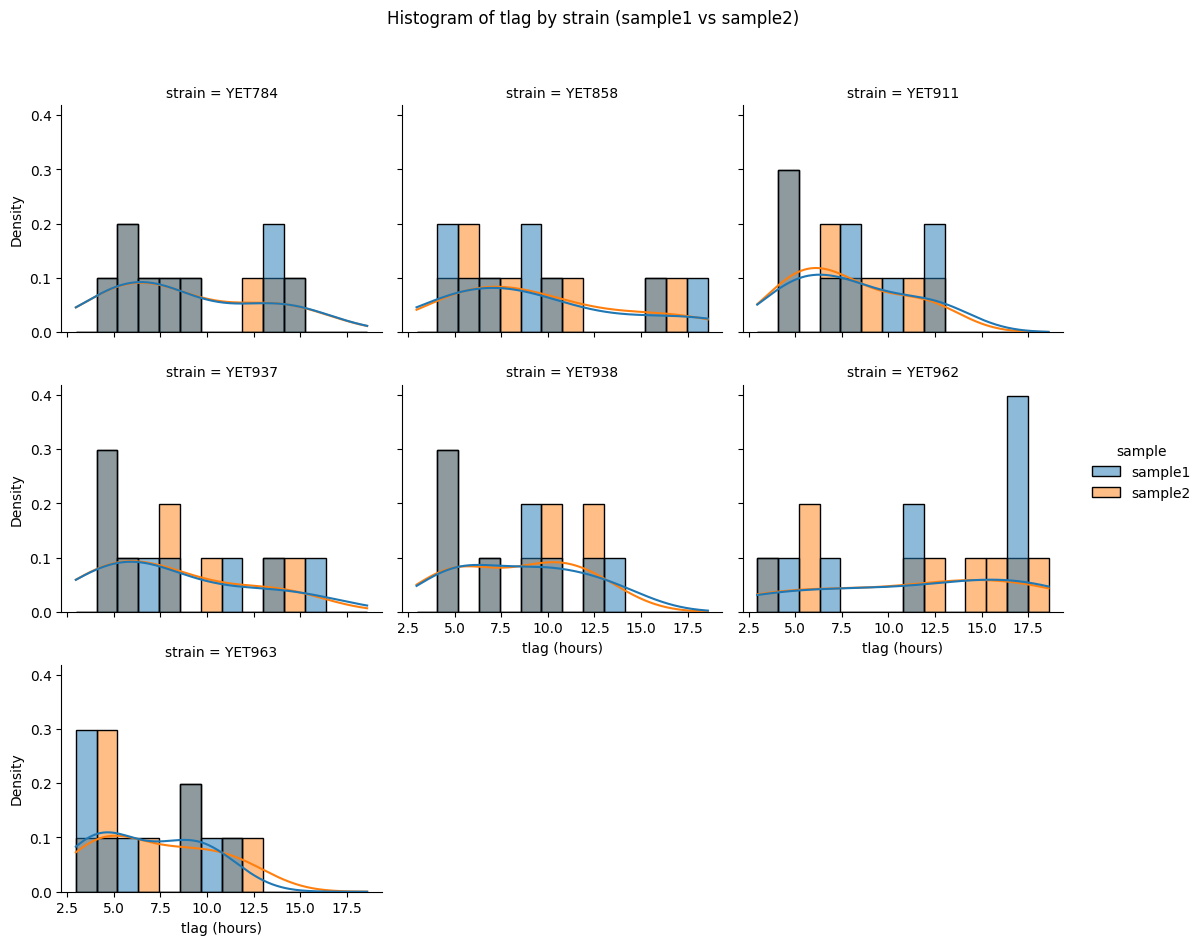

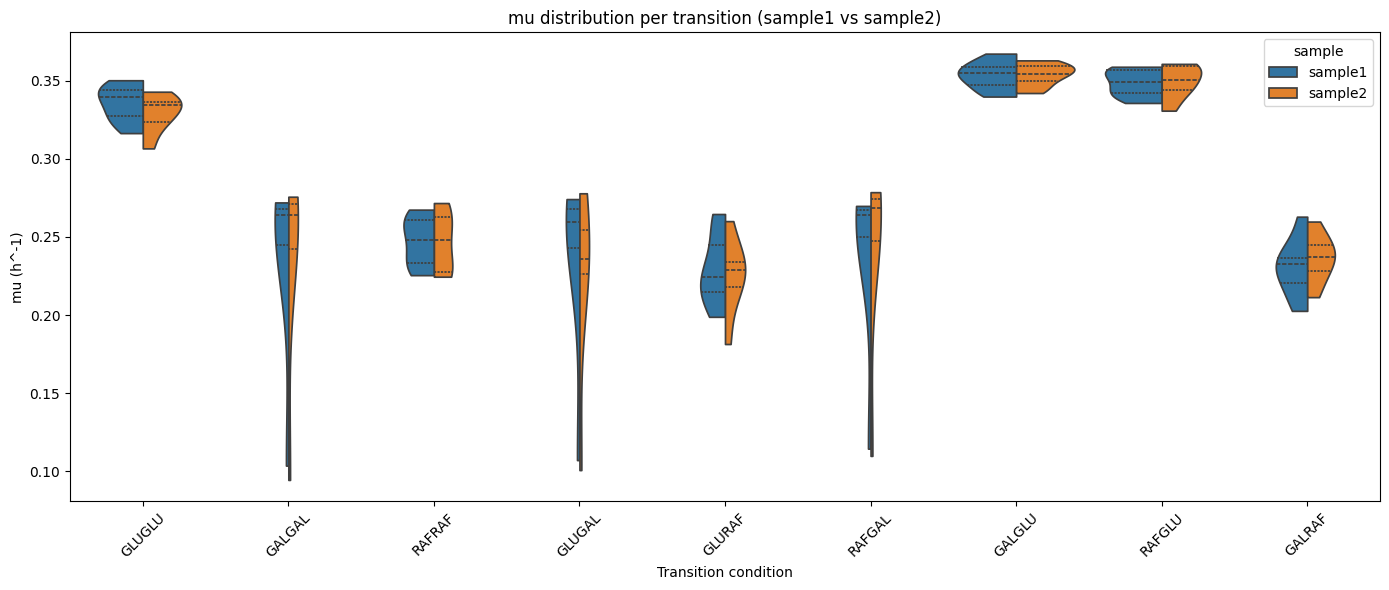

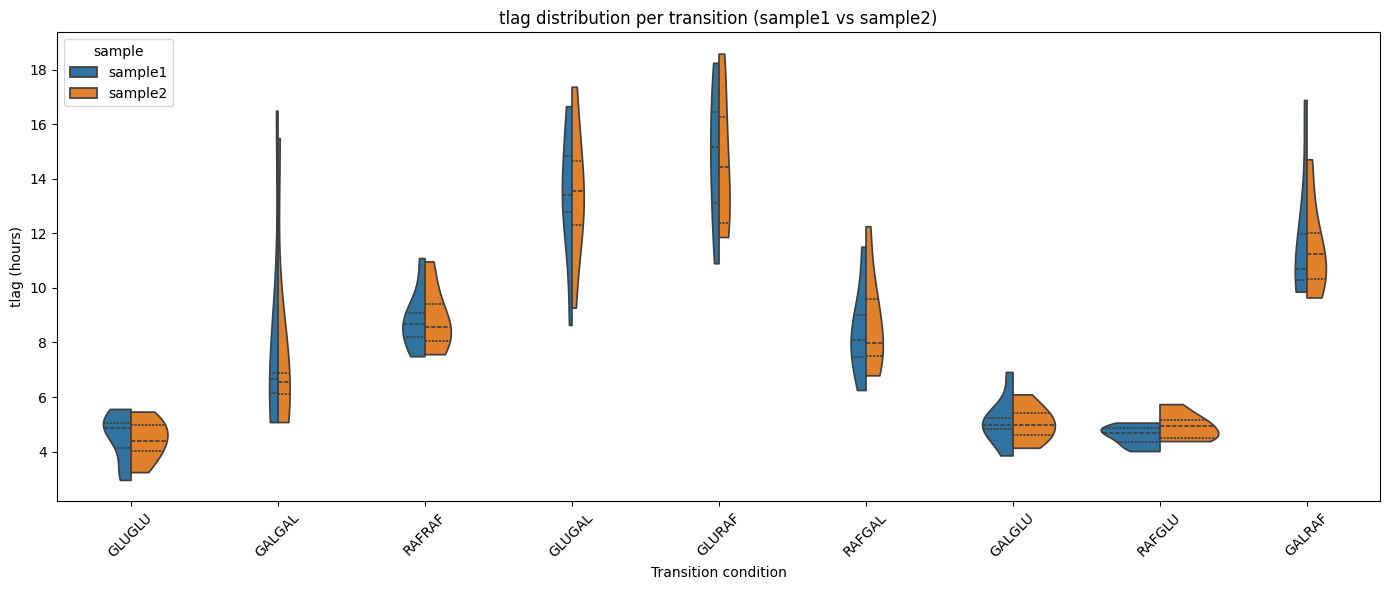

In [19]:
# Additional comparisons: strain vs sample + histograms
extra_plot_df = all_strains_results.copy()
extra_plot_df["mu"] = pd.to_numeric(extra_plot_df["mu"], errors="coerce")
extra_plot_df["tlag"] = pd.to_numeric(extra_plot_df["tlag"], errors="coerce")

mu_extra = extra_plot_df.dropna(subset=["condition", "strain", "sample", "mu"]).copy()
tlag_extra = extra_plot_df.dropna(subset=["condition", "strain", "sample", "tlag"]).copy()

print(f"mu rows for extra plots: {len(mu_extra)}")
print(f"tlag rows for extra plots: {len(tlag_extra)}")

# 1) Faceted box+strip plots: each strain separately, samples colored
if not mu_extra.empty:
    condition_order_mu = (
        mu_extra.groupby("condition")["mu"].median().sort_values(ascending=False).index.tolist()
    )
    g = sns.catplot(
        data=mu_extra,
        x="condition", y="mu",
        hue="sample",
        col="strain",
        kind="box",
        col_wrap=3,
        sharey=True,
        height=3.6,
        aspect=1.15,
        order=condition_order_mu,
        showfliers=False
    )
    g.set_xticklabels(rotation=45)
    g.set_axis_labels("Transition", "mu (h^-1)")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle("mu by transition, split by strain and sample")
    plt.show()

if not tlag_extra.empty:
    condition_order_tlag = (
        tlag_extra.groupby("condition")["tlag"].median().sort_values(ascending=True).index.tolist()
    )
    g = sns.catplot(
        data=tlag_extra,
        x="condition", y="tlag",
        hue="sample",
        col="strain",
        kind="box",
        col_wrap=3,
        sharey=True,
        height=3.6,
        aspect=1.15,
        order=condition_order_tlag,
        showfliers=False
    )
    g.set_xticklabels(rotation=45)
    g.set_axis_labels("Transition", "tlag (hours)")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle("tlag by transition, split by strain and sample")
    plt.show()

# 2) Point plots: direct sample1 vs sample2 comparison by strain
if not mu_extra.empty:
    plt.figure(figsize=(14, 6))
    sns.pointplot(
        data=mu_extra,
        x="condition", y="mu",
        hue="sample",
        dodge=0.35,
        errorbar="sd",
        markers=["o", "X"],
        linestyles=["-", "--"]
    )
    plt.title("mu comparison between sample1 and sample2 across transitions")
    plt.xlabel("Transition condition")
    plt.ylabel("mu (h^-1)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if not tlag_extra.empty:
    plt.figure(figsize=(14, 6))
    sns.pointplot(
        data=tlag_extra,
        x="condition", y="tlag",
        hue="sample",
        dodge=0.35,
        errorbar="sd",
        markers=["o", "X"],
        linestyles=["-", "--"]
    )
    plt.title("tlag comparison between sample1 and sample2 across transitions")
    plt.xlabel("Transition condition")
    plt.ylabel("tlag (hours)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3) Histograms: distribution of mu and tlag across strains with sample split
if not mu_extra.empty:
    g = sns.displot(
        data=mu_extra,
        x="mu",
        hue="sample",
        col="strain",
        col_wrap=3,
        kind="hist",
        bins=14,
        kde=True,
        stat="density",
        common_norm=False,
        height=3.2,
        aspect=1.15
    )
    g.set_axis_labels("mu (h^-1)", "Density")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle("Histogram of mu by strain (sample1 vs sample2)")
    plt.show()

if not tlag_extra.empty:
    g = sns.displot(
        data=tlag_extra,
        x="tlag",
        hue="sample",
        col="strain",
        col_wrap=3,
        kind="hist",
        bins=14,
        kde=True,
        stat="density",
        common_norm=False,
        height=3.2,
        aspect=1.15
    )
    g.set_axis_labels("tlag (hours)", "Density")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle("Histogram of tlag by strain (sample1 vs sample2)")
    plt.show()

# 4) Violin plots: show distribution shape per transition with sample split
if not mu_extra.empty:
    plt.figure(figsize=(14, 6))
    sns.violinplot(
        data=mu_extra,
        x="condition", y="mu",
        hue="sample",
        split=True,
        inner="quartile",
        cut=0
    )
    plt.title("mu distribution per transition (sample1 vs sample2)")
    plt.xlabel("Transition condition")
    plt.ylabel("mu (h^-1)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if not tlag_extra.empty:
    plt.figure(figsize=(14, 6))
    sns.violinplot(
        data=tlag_extra,
        x="condition", y="tlag",
        hue="sample",
        split=True,
        inner="quartile",
        cut=0
    )
    plt.title("tlag distribution per transition (sample1 vs sample2)")
    plt.xlabel("Transition condition")
    plt.ylabel("tlag (hours)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

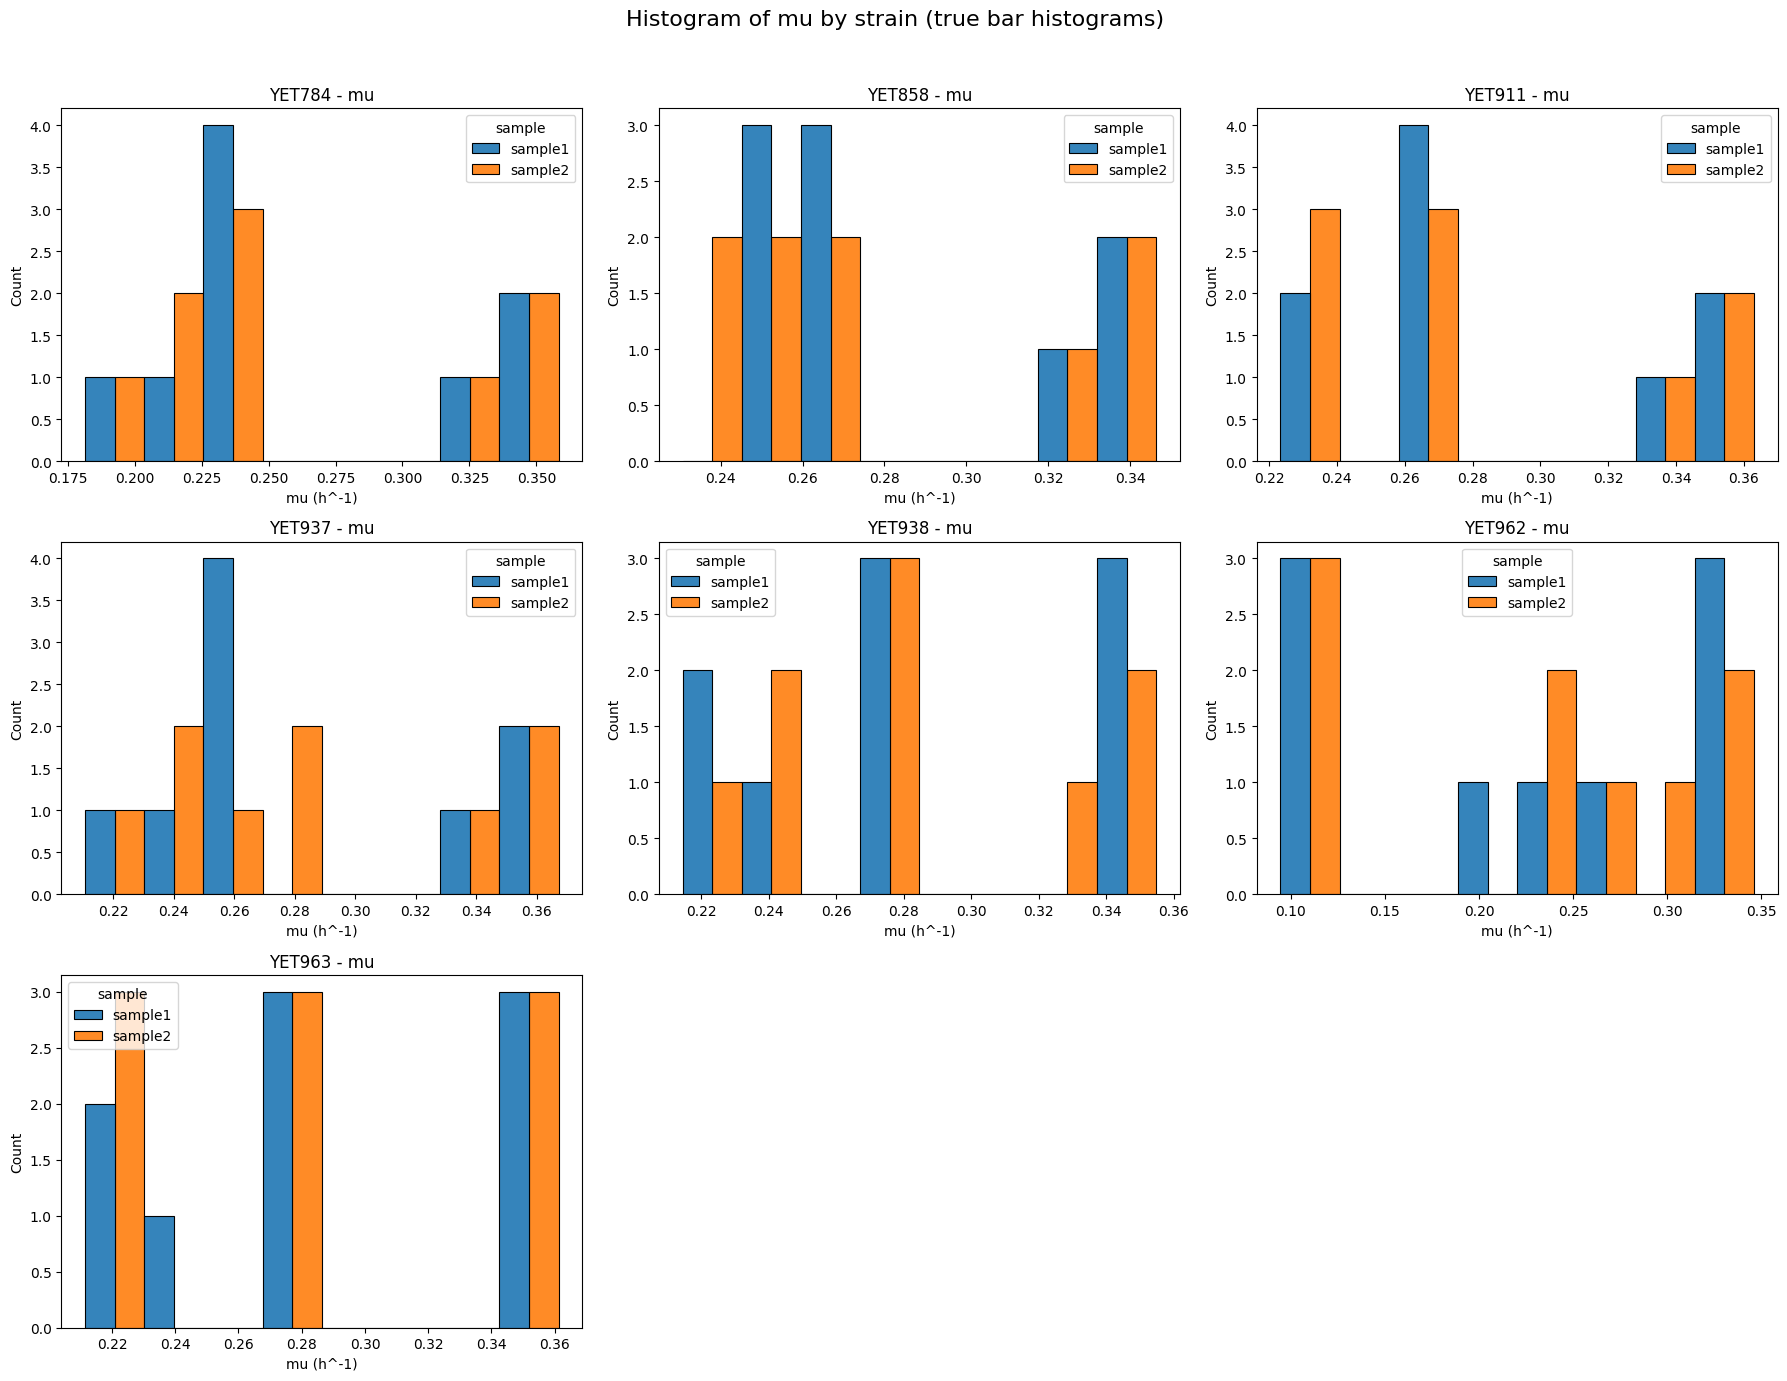

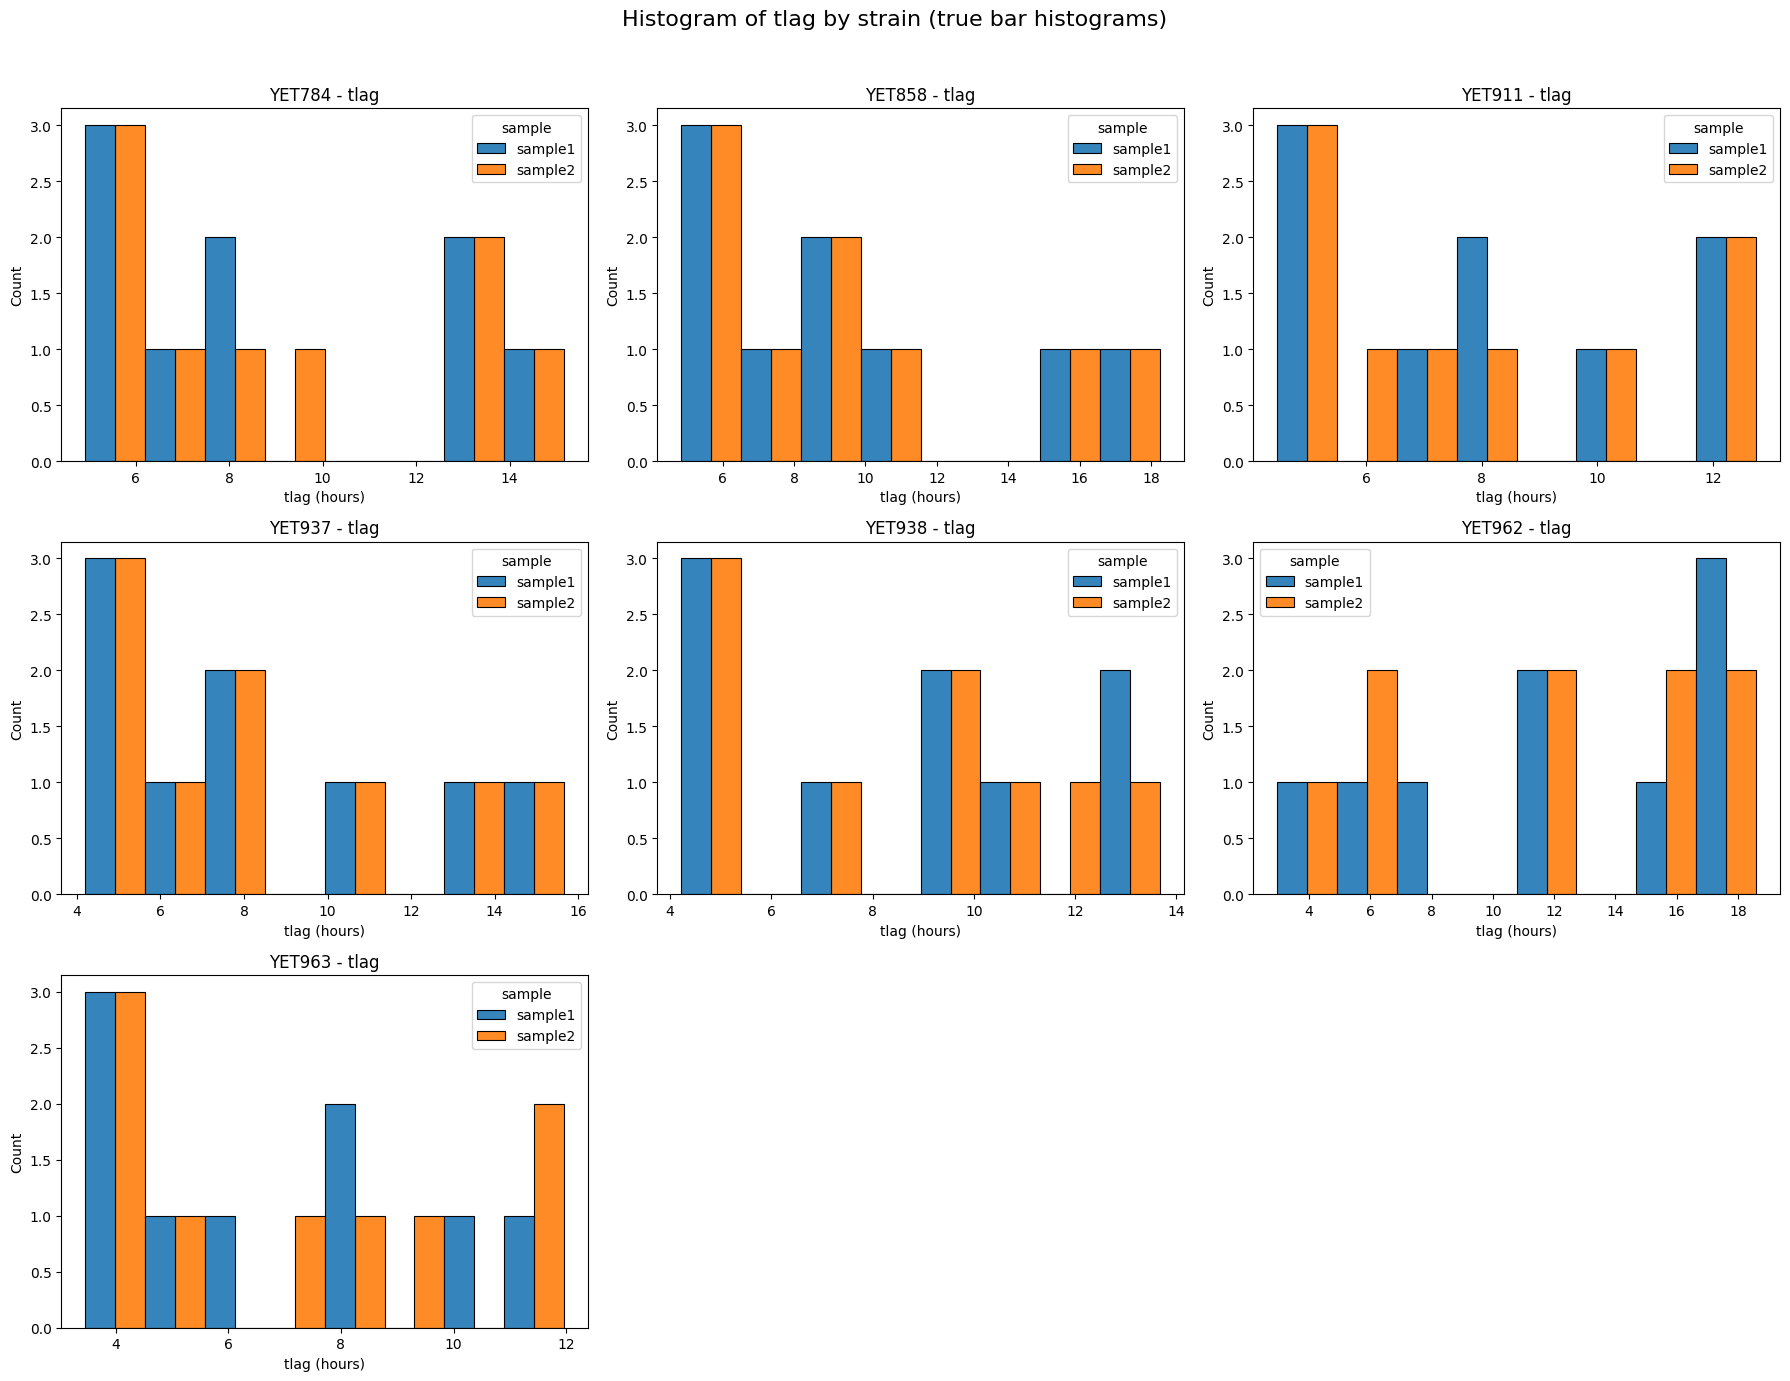

In [20]:
# Improved histograms (clear bars, no line-like KDE overlays)
import math

if 'mu_extra' not in globals() or 'tlag_extra' not in globals():
    extra_plot_df = all_strains_results.copy()
    extra_plot_df['mu'] = pd.to_numeric(extra_plot_df['mu'], errors='coerce')
    extra_plot_df['tlag'] = pd.to_numeric(extra_plot_df['tlag'], errors='coerce')
    mu_extra = extra_plot_df.dropna(subset=['condition', 'strain', 'sample', 'mu']).copy()
    tlag_extra = extra_plot_df.dropna(subset=['condition', 'strain', 'sample', 'tlag']).copy()

strain_order = sorted(all_strains_results['strain'].dropna().unique())
n_strains = len(strain_order)
n_cols = 3
n_rows = math.ceil(n_strains / n_cols)

# Histogram 1: mu
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for i, strain in enumerate(strain_order):
    ax = axes[i]
    d = mu_extra[mu_extra['strain'] == strain]
    sns.histplot(
        data=d,
        x='mu',
        hue='sample',
        bins=8,
        stat='count',
        multiple='dodge',
        element='bars',
        kde=False,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.9,
        ax=ax
    )
    ax.set_title(f'{strain} - mu')
    ax.set_xlabel('mu (h^-1)')
    ax.set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Histogram of mu by strain (true bar histograms)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Histogram 2: tlag
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for i, strain in enumerate(strain_order):
    ax = axes[i]
    d = tlag_extra[tlag_extra['strain'] == strain]
    sns.histplot(
        data=d,
        x='tlag',
        hue='sample',
        bins=8,
        stat='count',
        multiple='dodge',
        element='bars',
        kde=False,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.9,
        ax=ax
    )
    ax.set_title(f'{strain} - tlag')
    ax.set_xlabel('tlag (hours)')
    ax.set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Histogram of tlag by strain (true bar histograms)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

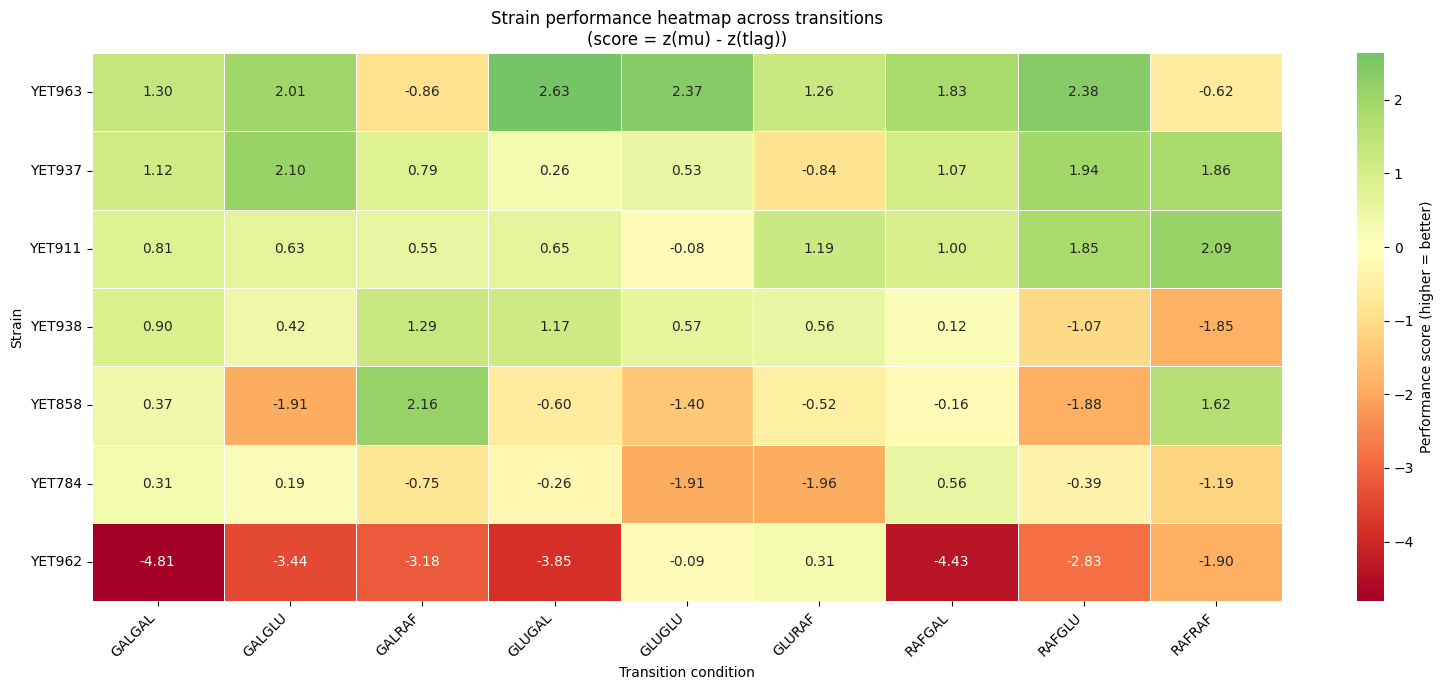

In [21]:
# One big color plot to compare strains clearly
score_df = all_strains_results.copy()
score_df["mu"] = pd.to_numeric(score_df["mu"], errors="coerce")
score_df["tlag"] = pd.to_numeric(score_df["tlag"], errors="coerce")

score_df = score_df.dropna(subset=["strain", "condition", "mu", "tlag"]).copy()
if score_df.empty:
    print("No valid rows for performance heatmap.")
else:
    # Aggregate across sample1/sample2 first
    perf = (
        score_df.groupby(["strain", "condition"], as_index=False)
        .agg(mu_mean=("mu", "mean"), tlag_mean=("tlag", "mean"))
    )

    # Build per-condition standardized score: higher = better
    # score = z(mu) - z(tlag), so high growth + short lag is high score
    perf["mu_z"] = perf.groupby("condition")["mu_mean"].transform(
        lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1)
    )
    perf["tlag_z"] = perf.groupby("condition")["tlag_mean"].transform(
        lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1)
    )
    perf["score"] = perf["mu_z"] - perf["tlag_z"]

    heat = perf.pivot(index="strain", columns="condition", values="score")

    # Order strains by overall average score for easier reading
    row_order = heat.mean(axis=1).sort_values(ascending=False).index
    heat = heat.loc[row_order]

    plt.figure(figsize=(16, 7))
    sns.heatmap(
        heat,
        cmap="RdYlGn",
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.7,
        cbar_kws={"label": "Performance score (higher = better)"}
    )
    plt.title("Strain performance heatmap across transitions\n(score = z(mu) - z(tlag))")
    plt.xlabel("Transition condition")
    plt.ylabel("Strain")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Optional quick ranking table
    strain_ranking = heat.mean(axis=1).sort_values(ascending=False).rename("mean_score")
    strain_ranking.to_frame()

Practical done! Make sure to save the figures you created for your report.